In [134]:
# Imported the csv file 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('facility_service_data_2022_2024.csv')

df.head(5)

,facility_id,facility_name,state,lga,report_month,hts_tst,hts_tst_pos,tx_new,tx_curr,tx_ml,pmtct_stat,pmtct_stat_pos,pmtct_art,tb_screen,tb_pos,vl_eligible,vl_result_received,vl_suppressed,date_submitted,reported_by
0,FCT012,Mission Hospital Bwari II,FCT,Bwari,30/11/2022,952,39,29,"2,721",23,300,9,8,2237,36,2271,1624,1396,2022-12-11,Data Clerk
1,FCT008,Teaching Hospital Gwagwalada II,FCT,Gwagwalada,30/04/2023,773,40,34,5094,42,102,1,0,2875,41,3722,2467,2342,2023-05-11,Data Clerk
2,NAS006,PRIMARY HEALTH CENTRE LAFIA II,Nasarawa,Lafia,2024-01-31,244,6,5,952,11,58,1,0,526,6,753,520,476,2024-02-18,Data Clerk
3,LAG004,COMPREHENSIVE HEALTH CENTRE SURULERE,Lagos,Surulere,2022-03-31,440,6,4,630,8,92,0,0,375,8,451,383,358,2022-04-15,Facility Focal Person
4,AKS005,Comprehensive Health Centre Oron,Akwa-Ibom,Oron,2022-01-31,76,0,0,1332,12,18,1,0,736,19,1145,685,644,2022-02-13,Data Clerk


In [135]:
# Changed the facility name, id's, state, and lga to uppercase.
df['state'] = df['state'].str.strip().str.upper()
df['facility_name'] = df['facility_name'].str.strip().str.upper()
df['facility_id'] = df['facility_id'].str.strip().str.upper()
df['lga'] = df['lga'].str.strip().str.upper()
df


,facility_id,facility_name,state,lga,report_month,hts_tst,hts_tst_pos,tx_new,tx_curr,tx_ml,pmtct_stat,pmtct_stat_pos,pmtct_art,tb_screen,tb_pos,vl_eligible,vl_result_received,vl_suppressed,date_submitted,reported_by
0,FCT012,MISSION HOSPITAL BWARI II,FCT,BWARI,30/11/2022,952,39,29,"2,721",23,300,9,8,2237,36,2271,1624,1396,2022-12-11,Data Clerk
1,FCT008,TEACHING HOSPITAL GWAGWALADA II,FCT,GWAGWALADA,30/04/2023,773,40,34,5094,42,102,1,0,2875,41,3722,2467,2342,2023-05-11,Data Clerk
2,NAS006,PRIMARY HEALTH CENTRE LAFIA II,NASARAWA,LAFIA,2024-01-31,244,6,5,952,11,58,1,0,526,6,753,520,476,2024-02-18,Data Clerk
3,LAG004,COMPREHENSIVE HEALTH CENTRE SURULERE,LAGOS,SURULERE,2022-03-31,440,6,4,630,8,92,0,0,375,8,451,383,358,2022-04-15,Facility Focal Person
4,AKS005,COMPREHENSIVE HEALTH CENTRE ORON,AKWA-IBOM,ORON,2022-01-31,76,0,0,1332,12,18,1,0,736,19,1145,685,644,2022-02-13,Data Clerk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4409,CRS006,PRIMARY HEALTH CENTRE CALABAR MUNICIPAL II,CROSS RIVER,CALABAR MUNICIPAL,2024-08-31,541,19,16,1437,11,128,4,3,1286,21,1279,1179,968,2024-09-13,Data Clerk
4410,AKS013,MODEL PRIMARY HEALTH CENTRE ABAK II,AKWA IBOM,ABAK,30/11/2024,306,20,16,722,3,43,2,1,555,8,520,427,388,2024-12-18,Data Clerk
4411,KAD012,COMPREHENSIVE HEALTH CENTRE KADUNA SOUTH II,KADUNA,KADUNA SOUTH,2022-04-30,323,3,2,660,7,84,3,2,403,11,573,316,306,2022-05-13,M&E Officer
4412,NAS001,MODEL PRIMARY HEALTH CENTRE LAFIA,NASARAWA,LAFIA,2022-03-31,128,,1,502,5,23,0,0,435,8,453,405,380,2022-04-11,Facility Focal Person


In [136]:
# Some states has two different spelling so i had to change them to just one
df["state"] = (
    df["state"].str.strip().str.upper().replace({
        "FCT": "FCT",
        "FEDERAL CAPITAL TERRITORY": "FCT",
        'F.C.T.': "FCT",
        "CROSS-RIVER": "CROSS RIVER",
        "AKWA-IBOM": "AKWA IBOM"
    })
)

df["state"].value_counts()

state
RIVERS         560
LAGOS          556
BENUE          555
KADUNA         553
NASARAWA       550
FCT            547
AKWA IBOM      547
CROSS RIVER    546
Name: count, dtype: int64

In [137]:
# Changed the dated to pandas date and time format
cols = ["report_month", "date_submitted"]

df[cols] = df[cols].apply(
    lambda col: pd.to_datetime(col, format="mixed" ,errors="coerce")
)
df[cols]

,report_month,date_submitted
0,2022-11-30,2022-12-11
1,2023-04-30,2023-05-11
2,2024-01-31,2024-02-18
3,2022-03-31,2022-04-15
4,2022-01-31,2022-02-13
...,...,...
4409,2024-08-31,2024-09-13
4410,2024-11-30,2024-12-18
4411,2022-04-30,2022-05-13
4412,2022-03-31,2022-04-11


In [138]:
# Created a seperate column for year, month and quarter
df['year'] = df['report_month'].dt.year
df['month'] = df['report_month'].dt.month
df['quarter'] = df['report_month'].dt.quarter
df


,facility_id,facility_name,state,lga,report_month,hts_tst,hts_tst_pos,tx_new,tx_curr,tx_ml,...,tb_screen,tb_pos,vl_eligible,vl_result_received,vl_suppressed,date_submitted,reported_by,year,month,quarter
0,FCT012,MISSION HOSPITAL BWARI II,FCT,BWARI,2022-11-30,952,39,29,"2,721",23,...,2237,36,2271,1624,1396,2022-12-11,Data Clerk,2022,11,4
1,FCT008,TEACHING HOSPITAL GWAGWALADA II,FCT,GWAGWALADA,2023-04-30,773,40,34,5094,42,...,2875,41,3722,2467,2342,2023-05-11,Data Clerk,2023,4,2
2,NAS006,PRIMARY HEALTH CENTRE LAFIA II,NASARAWA,LAFIA,2024-01-31,244,6,5,952,11,...,526,6,753,520,476,2024-02-18,Data Clerk,2024,1,1
3,LAG004,COMPREHENSIVE HEALTH CENTRE SURULERE,LAGOS,SURULERE,2022-03-31,440,6,4,630,8,...,375,8,451,383,358,2022-04-15,Facility Focal Person,2022,3,1
4,AKS005,COMPREHENSIVE HEALTH CENTRE ORON,AKWA IBOM,ORON,2022-01-31,76,0,0,1332,12,...,736,19,1145,685,644,2022-02-13,Data Clerk,2022,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4409,CRS006,PRIMARY HEALTH CENTRE CALABAR MUNICIPAL II,CROSS RIVER,CALABAR MUNICIPAL,2024-08-31,541,19,16,1437,11,...,1286,21,1279,1179,968,2024-09-13,Data Clerk,2024,8,3
4410,AKS013,MODEL PRIMARY HEALTH CENTRE ABAK II,AKWA IBOM,ABAK,2024-11-30,306,20,16,722,3,...,555,8,520,427,388,2024-12-18,Data Clerk,2024,11,4
4411,KAD012,COMPREHENSIVE HEALTH CENTRE KADUNA SOUTH II,KADUNA,KADUNA SOUTH,2022-04-30,323,3,2,660,7,...,403,11,573,316,306,2022-05-13,M&E Officer,2022,4,2
4412,NAS001,MODEL PRIMARY HEALTH CENTRE LAFIA,NASARAWA,LAFIA,2022-03-31,128,,1,502,5,...,435,8,453,405,380,2022-04-11,Facility Focal Person,2022,3,1


In [139]:
# Moved the year, month and quarter column from the end to just beside the report_month column from better reading
cols = df.columns.tolist()
cols.remove('year')
cols.remove('month')
cols.remove('quarter')

cols.insert(5, 'year')
cols.insert(6, 'month')
cols.insert(7, 'quarter')
df = df[cols]
df.tail(3)

,facility_id,facility_name,state,lga,report_month,year,month,quarter,hts_tst,hts_tst_pos,...,pmtct_stat,pmtct_stat_pos,pmtct_art,tb_screen,tb_pos,vl_eligible,vl_result_received,vl_suppressed,date_submitted,reported_by
4411,KAD012,COMPREHENSIVE HEALTH CENTRE KADUNA SOUTH II,KADUNA,KADUNA SOUTH,2022-04-30,2022,4,2,323,3,...,84,3,2,403,11,573,316,306,2022-05-13,M&E Officer
4412,NAS001,MODEL PRIMARY HEALTH CENTRE LAFIA,NASARAWA,LAFIA,2022-03-31,2022,3,1,128,,...,23,0,0,435,8,453,405,380,2022-04-11,Facility Focal Person
4413,RIV009,MISSION HOSPITAL KHANA II,RIVERS,KHANA,2024-09-30,2024,9,3,544,7,...,97,2,1,558,21,661,443,387,2024-10-15,Data Clerk


In [140]:
# validating the dates to make sure they fall under 2022 - 2024 and end of the month 
valid_dates = (
    df["report_month"].dt.year.between(2022, 2024)
    & df["report_month"].dt.is_month_end
)

df.loc[~valid_dates, "report_month"]

5      2022-05-01
10     2024-06-01
11     2023-02-01
24     2022-12-01
38     2024-12-01
          ...    
4382   2023-01-01
4383   2022-03-01
4394   2024-12-01
4399   2023-12-01
4406   2023-11-01
Name: report_month, Length: 441, dtype: datetime64[ns]

In [141]:
# Replaced ["", "N/A", "-", 'NULL', "nil"] with pandas NA
df.replace(["", "N/A", "-", 'NULL', "nil"], pd.NA, inplace= True)

In [142]:
df.head()

,facility_id,facility_name,state,lga,report_month,year,month,quarter,hts_tst,hts_tst_pos,...,pmtct_stat,pmtct_stat_pos,pmtct_art,tb_screen,tb_pos,vl_eligible,vl_result_received,vl_suppressed,date_submitted,reported_by
0,FCT012,MISSION HOSPITAL BWARI II,FCT,BWARI,2022-11-30,2022,11,4,952,39,...,300,9,8,2237,36,2271,1624,1396,2022-12-11,Data Clerk
1,FCT008,TEACHING HOSPITAL GWAGWALADA II,FCT,GWAGWALADA,2023-04-30,2023,4,2,773,40,...,102,1,0,2875,41,3722,2467,2342,2023-05-11,Data Clerk
2,NAS006,PRIMARY HEALTH CENTRE LAFIA II,NASARAWA,LAFIA,2024-01-31,2024,1,1,244,6,...,58,1,0,526,6,753,520,476,2024-02-18,Data Clerk
3,LAG004,COMPREHENSIVE HEALTH CENTRE SURULERE,LAGOS,SURULERE,2022-03-31,2022,3,1,440,6,...,92,0,0,375,8,451,383,358,2022-04-15,Facility Focal Person
4,AKS005,COMPREHENSIVE HEALTH CENTRE ORON,AKWA IBOM,ORON,2022-01-31,2022,1,1,76,0,...,18,1,0,736,19,1145,685,644,2022-02-13,Data Clerk


In [143]:
# Removed commas white spaces and convertes all the numbers from text to number 
cols = ["hts_tst", "hts_tst_pos", "tx_new", "tx_curr", "tx_ml", "pmtct_stat", "pmtct_stat_pos", "pmtct_art", "tb_screen", "tb_pos", "vl_eligible", "vl_result_received", "vl_suppressed"]

df[cols] = (df[cols].replace(",", "")
    .apply(lambda col: col.astype("string").str.strip())
    .apply(pd.to_numeric, errors="coerce"))

In [144]:
# Checking for negative values
negative_values = df[
    (df[cols] < 0).any(axis=1)
]

negative_values.head()

,facility_id,facility_name,state,lga,report_month,year,month,quarter,hts_tst,hts_tst_pos,...,pmtct_stat,pmtct_stat_pos,pmtct_art,tb_screen,tb_pos,vl_eligible,vl_result_received,vl_suppressed,date_submitted,reported_by
46,RIV010,TEACHING HOSPITAL AHOADA EAST II,RIVERS,AHOADA EAST,2022-06-30,2022,6,2,756.00,11.00,...,174.00,4,3,2272.00,48,3052.00,2439.00,2092.00,2022-07-21,M&E Officer
113,AKS009,PRIMARY HEALTH CENTRE IKOT EKPENE II,AKWA IBOM,IKOT EKPENE,2024-07-31,2024,7,3,109.00,6.00,...,27.00,1,0,137.00,2,190.00,145.00,135.00,2024-08-21,Data Clerk
339,AKS005,COMPREHENSIVE HEALTH CENTRE ORON,AKWA IBOM,ORON,2022-09-30,2022,9,3,127.00,0.00,...,27.00,0,0,1123.00,22,1113.00,687.00,649.00,2022-10-13,Facility Focal Person
510,BEN015,PRIMARY HEALTH CENTRE OTUKPO II,BENUE,OTUKPO,2022-07-31,2022,7,3,1440.00,3.00,...,18.00,0,0,764.00,9,733.00,605.00,526.00,2022-08-16,M&E Officer
582,LAG012,PRIMARY HEALTH CENTRE ALIMOSHO II,LAGOS,ALIMOSHO,2024-07-31,2024,7,3,382.00,18.00,...,82.00,1,0,597.00,7,597.00,474.00,445.00,2024-08-16,Facility Focal Person


In [145]:
# checked the number of duplicates in the dataset
df.duplicated().sum()

59

In [146]:
# Removed duplicates from the dataset
df = df.drop_duplicates(keep="first")
    

In [147]:
# Checking how many null values in each column
df.isna().sum()

facility_id             0
facility_name           0
state                   0
lga                     0
report_month            0
year                    0
month                   0
quarter                 0
hts_tst                77
hts_tst_pos            78
tx_new                 76
tx_curr               139
tx_ml                   0
pmtct_stat             77
pmtct_stat_pos          0
pmtct_art               0
tb_screen              79
tb_pos                  0
vl_eligible            78
vl_result_received     77
vl_suppressed          76
date_submitted          0
reported_by             0
dtype: int64

In [148]:
df.to_csv("cleaned_service_data.csv", index= False)

In [149]:
# Working on the facility master list
fm= pd.read_csv("facility_master_list.csv")
fm.head(5)


,facility_id,facility_name,state,lga,facility_level,ownership,setting,art_start_date,catchment_population,latitude,longitude
0,AKS001,Comprehensive Health Centre Uyo,Akwa Ibom,Uyo,Primary,Private,Urban,2015-04-22,79792.00,10.10,9.47
1,AKS002,General Hospital Ikot Ekpene,Akwa Ibom,Ikot Ekpene,Secondary,Public,Urban,2013-09-22,49951.00,7.02,4.10
2,AKS003,Model Primary Health Centre Eket,Akwa Ibom,Eket,Primary,Public,Rural,2022-04-04,32449.00,8.46,3.03
3,AKS004,Comprehensive Health Centre Etinan,Akwa Ibom,Etinan,Primary,Public,Rural,2018-09-03,193467.00,8.68,5.11
4,AKS005,Comprehensive Health Centre Oron,Akwa Ibom,Oron,Primary,Public,Rural,2020-08-04,72505.00,10.62,4.39


In [150]:
#Infor about that csv file
fm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   facility_id           126 non-null    object 
 1   facility_name         126 non-null    object 
 2   state                 126 non-null    object 
 3   lga                   126 non-null    object 
 4   facility_level        126 non-null    object 
 5   ownership             120 non-null    object 
 6   setting               120 non-null    object 
 7   art_start_date        126 non-null    object 
 8   catchment_population  120 non-null    float64
 9   latitude              126 non-null    float64
 10  longitude             126 non-null    float64
dtypes: float64(3), object(8)
memory usage: 11.0+ KB


In [151]:
#Checking for unique values
fm["facility_id"].is_unique

False

In [152]:
# checking duplicates from fm
master_duplicates = fm[
    fm["facility_id"].duplicated(keep=False)
]

master_duplicates

,facility_id,facility_name,state,lga,facility_level,ownership,setting,art_start_date,catchment_population,latitude,longitude
10,AKS011,Comprehensive Health Centre Etinan II,Akwa Ibom,Etinan,Primary,Private,Urban,2019-02-22,87342.00,6.43,4.63
125,AKS011,Comprehensive Health Centre Etinan II,Akwa Ibom,Etinan,Primary,Private,Urban,2019-02-22,87342.00,6.43,4.63


In [153]:
# checking if the facility id 
fm["facility_id"].head()

0    AKS001
1    AKS002
2    AKS003
3    AKS004
4    AKS005
Name: facility_id, dtype: object

In [154]:
# checking how many missing values exist
fm.isna().sum()

facility_id             0
facility_name           0
state                   0
lga                     0
facility_level          0
ownership               6
setting                 6
art_start_date          0
catchment_population    6
latitude                0
longitude               0
dtype: int64

In [155]:
# Removing duplicates from fm
fm.drop_duplicates(subset=["facility_id"], keep="first", inplace=True)


In [156]:
# Standardizing the facility id 
fm["facility_id"] = (fm["facility_id"].astype("string").str.strip().str.upper())

In [157]:
# Merging the facility id on both the facility master file and the facility service data 
merged = df.merge(
    fm,
    on="facility_id",
    how="outer",
    indicator=True
)


In [158]:
merged.columns

Index(['facility_id', 'facility_name_x', 'state_x', 'lga_x', 'report_month',
       'year', 'month', 'quarter', 'hts_tst', 'hts_tst_pos', 'tx_new',
       'tx_curr', 'tx_ml', 'pmtct_stat', 'pmtct_stat_pos', 'pmtct_art',
       'tb_screen', 'tb_pos', 'vl_eligible', 'vl_result_received',
       'vl_suppressed', 'date_submitted', 'reported_by', 'facility_name_y',
       'state_y', 'lga_y', 'facility_level', 'ownership', 'setting',
       'art_start_date', 'catchment_population', 'latitude', 'longitude',
       '_merge'],
      dtype='object')

In [159]:
# Checking the merge outcome
merged["_merge"].value_counts()

_merge
both          4175
left_only      180
right_only       5
Name: count, dtype: int64

In [160]:
# checking the merge on the left
fmna = merged[
    merged["_merge"] == "left_only"
]
fmna.head()

,facility_id,facility_name_x,state_x,lga_x,report_month,year,month,quarter,hts_tst,hts_tst_pos,...,state_y,lga_y,facility_level,ownership,setting,art_start_date,catchment_population,latitude,longitude,_merge
1433,LAG099,GENERAL HOSPITAL CHIKUN II,KADUNA,CHIKUN,2024-05-31,2024.00,5.00,2.00,361.00,11.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
1434,LAG099,SPECIALIST HOSPITAL ALIMOSHO,LAGOS,ALIMOSHO,2023-05-31,2023.00,5.00,2.00,1093.00,23.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
1435,LAG099,MODEL PRIMARY HEALTH CENTRE KADUNA NORTH,KADUNA,KADUNA NORTH,2023-04-30,2023.00,4.00,2.00,251.00,14.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
1436,LAG099,COTTAGE HOSPITAL GWAGWALADA II,FCT,GWAGWALADA,2024-06-30,2024.00,6.00,2.00,1377.00,19.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
1437,LAG099,MODEL PRIMARY HEALTH CENTRE KATSINA-ALA II,BENUE,KATSINA-ALA,2023-04-30,2023.00,4.00,2.00,255.00,6.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [161]:
# checking the merge on the right
fmnaa = merged[
    merged["_merge"] == "right_only"
]
fmnaa

,facility_id,facility_name_x,state_x,lga_x,report_month,year,month,quarter,hts_tst,hts_tst_pos,...,state_y,lga_y,facility_level,ownership,setting,art_start_date,catchment_population,latitude,longitude,_merge
4355,NEW001,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,...,Cross River,Obudu,Primary,Private,Urban,2018-08-05,155505.00,11.32,9.02,right_only
4356,NEW002,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,...,Cross River,Calabar Municipal,Primary,Public,Rural,2020-03-08,195430.00,9.40,3.56,right_only
4357,NEW003,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,...,Akwa Ibom,Abak,Primary,Public,Rural,2016-08-10,70260.00,6.38,3.46,right_only
4358,NEW004,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,...,Nasarawa,Karu,Secondary,Private,Urban,2014-08-25,197190.00,9.06,7.19,right_only
4359,NEW005,NaN,NaN,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,...,Cross River,Ikom,Primary,Public,Rural,2017-10-18,46195.00,5.01,5.09,right_only


In [162]:
#Cross checking
df.shape

(4355, 23)

In [163]:
#Cross checking
df.columns

Index(['facility_id', 'facility_name', 'state', 'lga', 'report_month', 'year',
       'month', 'quarter', 'hts_tst', 'hts_tst_pos', 'tx_new', 'tx_curr',
       'tx_ml', 'pmtct_stat', 'pmtct_stat_pos', 'pmtct_art', 'tb_screen',
       'tb_pos', 'vl_eligible', 'vl_result_received', 'vl_suppressed',
       'date_submitted', 'reported_by'],
      dtype='object')

In [164]:
# checkingb the datatypes of the report month and date submitted
df[["report_month", "date_submitted"]].dtypes

report_month      datetime64[ns]
date_submitted    datetime64[ns]
dtype: object

In [165]:
# Creating a list of all the columns i want to work with for the validation fucntions 
lists = [
    "hts_tst",
    "hts_tst_pos",
    "tx_new",
    "tx_curr",
    "tx_ml",
    "pmtct_stat",
    "pmtct_stat_pos",
    "pmtct_art",
    "tb_screen",
    "tb_pos",
    "vl_eligible",
    "vl_result_received",
    "vl_suppressed"
]

In [166]:
# This function creates a table with the rows that faild the validation 
def make_issue(df, mask, rule_id, description, observed):
    result = df.loc[
        mask,
        ["facility_id", "report_month"]
    ].copy()

    result["rule_id"] = rule_id
    result["description"] = description
    result["observed"] = observed.loc[mask].astype("string")

    return result[
        ["facility_id", "report_month", "rule_id", "description", "observed"]
    ]

In [167]:
# function that makes sure hts_tst_pos <= hts_tst
def r1(df):
    mask = (
        df["hts_tst_pos"].notna() &
        df["hts_tst"].notna() & (df["hts_tst_pos"] > df["hts_tst"])
    )

    observed = (
        df["hts_tst_pos"].astype("string")+ " > " +df["hts_tst"].astype("string")
    )

    return make_issue(
        df,
        mask,
        "R1",
        "hts_tst_pos must be less than or equal to hts_tst",
        observed
    )

In [168]:
# this function	checks if pmtct_stat_pos <= pmtct_stat, and pmtct_art <= pmtct_stat_pos
def r2(df):
    condition_1 = (
        df["pmtct_stat_pos"].notna() &
        df["pmtct_stat"].notna() &
        (df["pmtct_stat_pos"] > df["pmtct_stat"])
    )

    condition_2 = (
        df["pmtct_art"].notna() &
        df["pmtct_stat_pos"].notna() &
      (df["pmtct_art"] > df["pmtct_stat_pos"])
    )

    mask = condition_1 | condition_2

    observed = (
        "pmtct_stat_pos=" + df["pmtct_stat_pos"].astype("string") +
        ", pmtct_stat=" + df["pmtct_stat"].astype("string") +
        ", pmtct_art=" + df["pmtct_art"].astype("string")
    )

    return make_issue(
        df,
        mask,
        "R2",
        "PMTCT cascade relationship is invalid",
        observed
    )

In [169]:
# r3 validates that vl_result_received should be <= vl_eligible, and vl_suppressed should be <= vl_result_received
def r3(df):
    condition_1 = (
        df["vl_result_received"].notna() &
        df["vl_eligible"].notna() &
        (df["vl_result_received"] > df["vl_eligible"])
    )

    condition_2 = (
        df["vl_suppressed"].notna() &
        df["vl_result_received"].notna() &
        (df["vl_suppressed"] > df["vl_result_received"])
    )

    mask = condition_1 | condition_2

    observed = (
        "vl_eligible=" + df["vl_eligible"].astype("string") +
        ", vl_result_received=" + df["vl_result_received"].astype("string") +", vl_suppressed=" + df["vl_suppressed"].astype("string")
    )

    return make_issue(
        df,
        mask,
        "R3",
        "Viral load cascade relationship is invalid",
        observed
    )

In [170]:
# r4 checks if tb_pos <= tb_screen.	Same logic as r1, r2 and r3.
def r4(df):
    mask = (
        df["tb_pos"].notna() &
        df["tb_screen"].notna() &
        (df["tb_pos"] > df["tb_screen"])
    )

    observed = (
        df["tb_pos"].astype("string")
        + " > " +
        df["tb_screen"].astype("string")
    )

    return make_issue(
        df,
        mask,
        "R4",
        "tb_pos must be less than or equal to tb_screen",
        observed
    )

In [171]:
# r5 checks for values in the list array that is less than 0
def r5(df):
    mask = df[lists].lt(0).any(axis=1)

    observed = df[lists].where(df[lists].lt(0)).apply(
        lambda row: row.dropna().to_dict(), axis=1).astype("string")

    return make_issue(
        df,
        mask,
        "R5",
        "Negative values are not allowed",
        observed
    )
    

In [172]:
# r6 check if positivity yield is between 0.1% and 15%
def r6(df):
    valid = (
        df["hts_tst"].notna() &
        df["hts_tst_pos"].notna() &
        (df["hts_tst"] > 0) 
    )

    yield_pct = (
        df["hts_tst_pos"] / df["hts_tst"] * 100
    )

    mask = valid & (
        (yield_pct < 0.1) | (yield_pct > 15)
    )

    observed = yield_pct.round(2).astype("string") + "%"

    return make_issue(
        df, 
        mask,
        "R6",
        "HTS positively yield must be between 0.1%, and 15%",
        observed
    )

In [173]:
# hts_tst month change in hts_tst that is under 300%
def r7(df):
    previous = (
        df.groupby("facility_id")
        ["hts_tst"].shift(1)
    )

    valid = (
        df["hts_tst"].notna() &
        previous.notna() &
        (previous > 0)
    )

    change_pct = (
        (df["hts_tst"] - previous).abs()
        /previous * 100)

    mask = valid & (change_pct >= 300)

    observed = change_pct.round(2).astype("string") + "% change"

    return make_issue(
        df, 
        mask,
        "R7",
        "Month-on-month change in hts_tst must be under 300%",
        observed
    )

In [174]:
# r8 check if each facility has 36 report_months 
def r8(df):
    count = (
        df.groupby("facility_id")
        ["report_month"].nunique()
    )

    incomplete_facilities = count[count != 36]

    mask = df["facility_id"].isin(
        incomplete_facilities.index
    )

    observed = (
        df["facility_id"].map(count).astype("string")+ "/36 monthly records"
    )

    return make_issue(
        df, 
        mask, 
        "R8",
        "Each facility should have 36 monthly recodrs",
        observed
    )

In [175]:
# the date submitted must be after the reporting month has ended
def r9(df):
    mask = (
        df["date_submitted"].notna()&
        df["report_month"].notna()&
        (df["date_submitted"] <= df["report_month"])
    )

    observed = (
        "submitted=" +
        df["date_submitted"].astype("string") + ", period_end=" + df["report_month"].astype("string")
    )

    return make_issue(
        df,
        mask,
        "R9",
        "date_submitted must be after the reporting period end",
        observed
    )

In [176]:
# the date submitted must be wthin 15 days of the report month ending
def r10(df):
    day_late = (
        df["date_submitted"] - df["report_month"]
    ).dt.days

    mask = (
        df["date_submitted"].notna()&
        df["report_month"].notna()&
        (day_late > 15)
    )

    observed = (
        day_late.astype("string") + " days"
    )

    return make_issue(
        df,
        mask,
        "R10",
        "Report should be submitted within 15 days of period end",
        observed
    )

In [177]:
# It check if the current tx is eqaul to the expected current tx
def r11(df):
    previous_tx_curr = (
        df.groupby("facility_id")["tx_curr"].shift(1)
    )

    expected_tx_curr = (
        previous_tx_curr + df["tx_new"]- df["tx_ml"]
    )

    valid = (
        previous_tx_curr.notna()& df["tx_curr"].notna()& df["tx_ml"].notna()& df["tx_new"].notna()
    )

    mask = valid & (
        df["tx_curr"] != expected_tx_curr
    )

    observed = (
        "actual=" + df["tx_curr"].astype("string") + ", expected=" + expected_tx_curr.astype("string")
    )

    return make_issue(
        df, 
        mask,
        "R11",
        "tx_curr should approximately equal previous tx_curr + tx_new - tx_ml",
        observed
    )

In [178]:
# this basically stacks the function results and prints on issues dataframe
issues = pd.concat(
    [           # Data-quality Dimensions
        r1(df), #Consistency/Integrity
        r2(df), #Consistency/ Integrity
        r3(df), # Consistency/Integrity
        r4(df), # Consistency/Integrity
        r5(df), # Integrity
        r6(df), # Accuracy
        r7(df), # Accuracy
        r8(df), # Completness
        r9(df), # Timeliness
        r10(df),# Timeliness
        r11(df) #Integrity / Consistency
    ],
    ignore_index= True
)

In [179]:
# checking the issues df
issues.head()

,facility_id,report_month,rule_id,description,observed
0,LAG003,2024-03-31,R1,hts_tst_pos must be less than or equal to hts_tst,3407.0 > 3384.0
1,FCT005,2023-02-28,R1,hts_tst_pos must be less than or equal to hts_tst,443.0 > 403.0
2,RIV014,2023-06-30,R1,hts_tst_pos must be less than or equal to hts_tst,1085.0 > 1064.0
3,BEN012,2024-08-01,R1,hts_tst_pos must be less than or equal to hts_tst,615.0 > 572.0
4,NAS999,2024-04-30,R1,hts_tst_pos must be less than or equal to hts_tst,693.0 > 646.0


In [180]:
# checkijng how many facilities has uses in each of the validation rules
issues["rule_id"].value_counts()

rule_id
R11    3773
R8     3520
R10    2204
R6      135
R1       50
R3       46
R7       44
R5       41
R2       21
R9       17
R4       10
Name: count, dtype: int64

Based on the validations we have done across the facility_service_data_2022-2024 we can to a conclusion that rule R11 was the most violated with 3773 issues, followed by R8 with 3520, R10 with 2204, and R6 with 2204

In [181]:
issues["facility_id"].value_counts().head(10)

facility_id
XXX999    130
NAS999    124
TMP001    112
LAG099    110
RIV001    103
CRS010     96
CRS007     94
AKS005     94
NAS007     94
FCT005     94
Name: count, dtype: int64

In [182]:
# Above are the top 10 facilities with the most violations

In [183]:
# From df we get the facility_id and their states and remove all duplicates 
facility_state = (
    df[["facility_id", "state"]].drop_duplicates()
)

In [184]:
# We then merge the Facility states with the issues with the common column facility_id, because the issues didn't have a state column
issues_with_state = issues.merge(
    facility_state,
    on="facility_id",
    how="left"
)


In [185]:
# The top 10 states with the most issues
issues_with_state["state"].value_counts().head(10)
    

state
RIVERS         1714
NASARAWA       1676
KADUNA         1674
AKWA IBOM      1671
LAGOS          1656
CROSS RIVER    1627
BENUE          1616
FCT            1559
Name: count, dtype: int64

In [186]:
# Converted all the issue validations to a CSV file
issues.to_csv("issues_log.csv", index = False)

In [187]:
# Imported the hts_age_sex_disaggregation_2024.csv
ds = pd.read_csv("hts_age_sex_disaggregation_2024.csv")
ds.head()

,facility_id,report_month,sex,age_band,hts_tst,hts_tst_pos
0,AKS001,2024-01,Female,<15,24,0
1,AKS001,2024-01,Female,15-24,63,0
2,AKS001,2024-01,Female,25-34,63,0
3,AKS001,2024-01,Female,35-49,51,NaN
4,AKS001,2024-01,Female,50+,27,0


In [188]:
# Standardizing the sex column to just Male and Female
sex = {
    "Female": "Female",
    "female": "Female",
    "F": "Female",
    "f": "Female",
    "Male": "Male",
    "male": "Male",
    "M": "Male",
    "m": "Male"
}

ds["sex"] = ds["sex"].replace(sex)
ds["sex"].unique()


array(['Female', 'Male'], dtype=object)

In [189]:
# Value count on how many males and females 
ds["sex"].value_counts()

sex
Female    7200
Male      7200
Name: count, dtype: int64

In [190]:
# value count on the age band 
ds["age_band"].value_counts()

age_band
25-34           2880
35-49           2880
<15             2703
15-24           2700
50+             2700
15 - 24          180
50 and above     180
0-14             177
Name: count, dtype: int64

In [191]:
# standardizing the age band to just 5 age bands 
age_map = {
    "<15": "0-14",
    "0-14": "0-14",
    "15-24": "15-24",
    "15 - 24": "15-24",
    "50+": "50+",
    "50 and above": "50+"
}

ds["age_band"] = ds["age_band"].replace(age_map)

In [192]:
# Checking the age band 
ds["age_band"].unique()

array(['0-14', '15-24', '25-34', '35-49', '50+'], dtype=object)

In [193]:
# created a new column age_sex 
ds["age_sex"] = (
    ds["sex"] + " " + ds["age_band"]
)

In [194]:
# checking the age_sex column, below i checked my hts_tst data type and it said it was an object so i had comeup and change the hts type to numeric so eveything i had previously worked on would be in a numberic format

ds["hts_tst"] = pd.to_numeric(ds["hts_tst"], errors="coerce")

In [195]:
# making a pivot wide table with the facility id and report month as index and the columns as age_sex values, the values under the age_sex are gotten from the sum of the hts_tst  
wide = ds.pivot_table(
    index=["facility_id", "report_month"],
    columns="age_sex",
    values=  "hts_tst",
    aggfunc="sum",
    fill_value=0
).reset_index()


In [196]:
# Checking the wide table
wide.head()

age_sex,facility_id,report_month,Female 0-14,Female 15-24,Female 25-34,Female 35-49,Female 50+,Male 0-14,Male 15-24,Male 25-34,Male 35-49,Male 50+
0,AKS001,2024-01,24.00,63.00,63.00,51.00,27.00,14.00,48.00,53.00,34.00,16.00
1,AKS001,2024-02,32.00,113.00,123.00,91.00,37.00,25.00,89.00,90.00,55.00,26.00
2,AKS001,2024-03,33.00,99.00,93.00,76.00,31.00,25.00,57.00,77.00,54.00,26.00
3,AKS001,2024-04,30.00,86.00,117.00,81.00,32.00,23.00,67.00,84.00,53.00,23.00
4,AKS001,2024-05,34.00,110.00,117.00,90.00,37.00,30.00,81.00,80.00,65.00,23.00


In [197]:
# checking the pivot wide columns 
wide.columns

Index(['facility_id', 'report_month', 'Female 0-14', 'Female 15-24',
       'Female 25-34', 'Female 35-49', 'Female 50+', 'Male 0-14', 'Male 15-24',
       'Male 25-34', 'Male 35-49', 'Male 50+'],
      dtype='object', name='age_sex')

In [198]:
# .melt is used to change back from wide to long, so the age_sex values are no more columns but now rows and the values of the sex_age are now in a column called value 
long_again = wide.melt(
    id_vars=["facility_id", "report_month"],
    var_name="sex_age",
    value_name= "hts_tst"
)
long_again.head()

,facility_id,report_month,sex_age,hts_tst
0,AKS001,2024-01,Female 0-14,24.00
1,AKS001,2024-02,Female 0-14,32.00
2,AKS001,2024-03,Female 0-14,33.00
3,AKS001,2024-04,Female 0-14,30.00
4,AKS001,2024-05,Female 0-14,34.00


In [199]:
# i have to change report_month to pd.to_datetime
ds["report_month"] = pd.to_datetime(ds["report_month"], errors="coerce")

In [200]:
# then i created a column called year from the report month 
ds["year"] = ds["report_month"].dt.year

In [201]:
# i grouped the facility and the facility year with the sum of the hts_tst values 
facility_year = (
    ds.groupby(["facility_id", "year"])
    ["hts_tst"].sum().reset_index()
    )
facility_year.head()

,facility_id,year,hts_tst
0,AKS001,2024,7281.00
1,AKS002,2024,3324.00
2,AKS003,2024,7896.00
3,AKS004,2024,2910.00
4,AKS005,2024,1627.00


In [202]:
facility_year.count()

facility_id    120
year           120
hts_tst        120
dtype: int64

In [203]:
# From the facility service data file i made sure the report month had a date and time data type
df["report_month"] = pd.to_datetime(df["report_month"])

In [204]:
# i got the year out from the reprot month using dt.year
df["year"] = df["report_month"].dt.year

In [205]:
# I made a copy of the column year only containing the 2024 reports 
aggregate_2024 = df[df["year"] == 2024].copy()

In [206]:
# Checkinng duplicate from the aggregate 2024
duplicates = aggregate_2024[
    aggregate_2024.duplicated(
        subset=["facility_id", "report_month"],
        keep=False
    )
]

In [207]:
# getting the sum of the hts_tst reprot month from the facility_id and 2024 year 
aggregate_total_2024 = (
    aggregate_2024
    .groupby(["facility_id", "year"], as_index= False)
    ["hts_tst"].sum()
)
aggregate_total_2024.head()

,facility_id,year,hts_tst
0,AKS001,2024,6787.00
1,AKS002,2024,3382.00
2,AKS003,2024,6565.00
3,AKS004,2024,2775.00
4,AKS005,2024,1549.00


In [208]:
# merging the aggregate total from the facility service data 2024 to the facility year data frame
compare = pd.merge(
    facility_year,
    aggregate_total_2024,
    on=["facility_id", "year"],
    how="outer",
    suffixes=("_disagg", "_agg")
)
compare.head(10)

,facility_id,year,hts_tst_disagg,hts_tst_agg
0,AKS001,2024,7281.00,6787.00
1,AKS002,2024,3324.00,3382.00
2,AKS003,2024,7896.00,6565.00
3,AKS004,2024,2910.00,2775.00
4,AKS005,2024,1627.00,1549.00
5,AKS006,2024,6453.00,6515.00
6,AKS007,2024,13211.00,12471.00
7,AKS008,2024,1142.00,1101.00
8,AKS009,2024,1057.00,1127.00
9,AKS010,2024,7784.00,7259.00


In [209]:
# calculating the percentage difference between the aggregated hts_tst and the disaggregated hts_tst
compare["pctg_diff"]=(
    abs(
        compare["hts_tst_disagg"] - compare["hts_tst_agg"]
    )/compare["hts_tst_agg"] * 100
)
compare["pctg_diff"].head(10)

0    7.28
1    1.71
2   20.27
3    4.86
4    5.04
5    0.95
6    5.93
7    3.72
8    6.21
9    7.23
Name: pctg_diff, dtype: Float64

In [210]:
# i create a column called flag that is true if the pctg_diff is greater than 5
compare["flag"] = (
    compare["pctg_diff"]>5
)


In [211]:
# flag_disagg contains only facilites that pctg_diff is greater that 5%
flag_disagg = compare[compare["pctg_diff"]>5]
flag_disagg.head(10)

,facility_id,year,hts_tst_disagg,hts_tst_agg,pctg_diff,flag
0,AKS001,2024,7281.00,6787.00,7.28,True
2,AKS003,2024,7896.00,6565.00,20.27,True
4,AKS005,2024,1627.00,1549.00,5.04,True
6,AKS007,2024,13211.00,12471.00,5.93,True
8,AKS009,2024,1057.00,1127.00,6.21,True
9,AKS010,2024,7784.00,7259.00,7.23,True
12,AKS013,2024,4954.00,4626.00,7.09,True
17,BEN003,2024,7245.00,6378.00,13.59,True
18,BEN004,2024,12729.00,11709.00,8.71,True
19,BEN005,2024,6966.00,7750.00,10.12,True


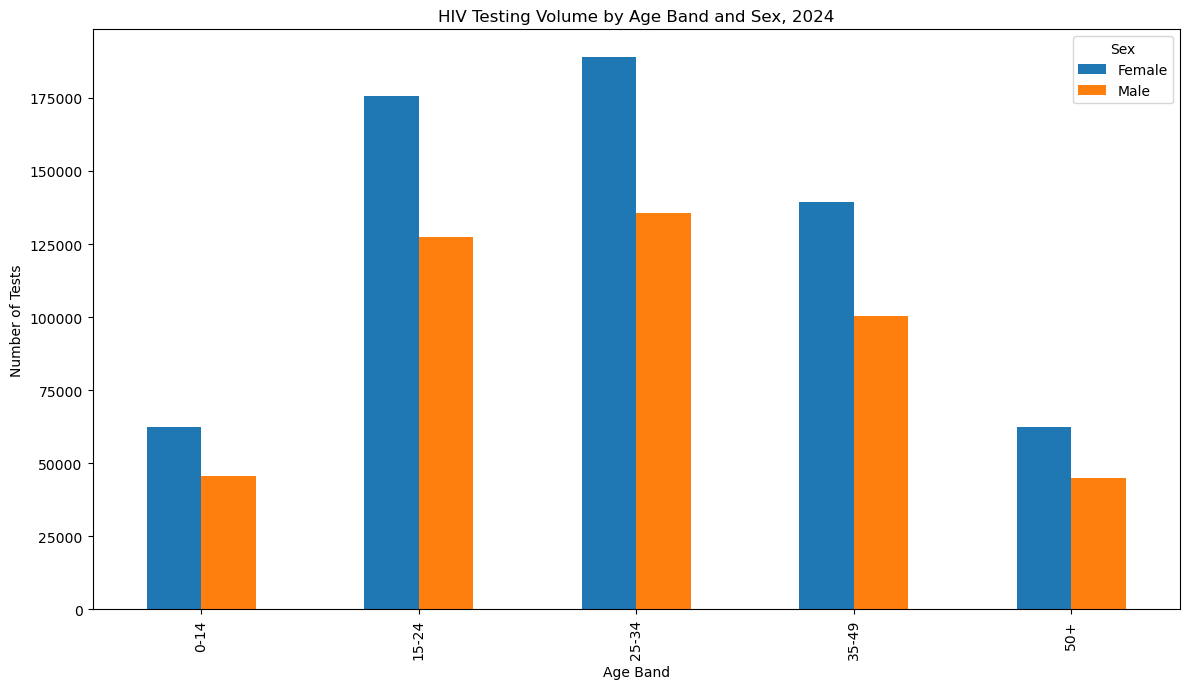

In [212]:
# Filter to 2024
age_sex_2024 = ds[
    ds["year"] == 2024
].copy()

# Aggregate testing volume
age_sex_summary = (
    age_sex_2024
    .groupby(["age_band", "sex"])
    ["hts_tst"].sum()
    .reset_index()
)

# Pivot so sex becomes columns
age_sex_pivot = age_sex_summary.pivot(
    index="age_band",
    columns="sex",
    values="hts_tst"
).fillna(0)

# Plot
ax = age_sex_pivot.plot(
    kind="bar",
    figsize=(12, 7)
)

ax.set_title("HIV Testing Volume by Age Band and Sex, 2024")
ax.set_xlabel("Age Band")
ax.set_ylabel("Number of Tests")


plt.legend(title="Sex")

plt.tight_layout()

plt.savefig(
    "plot_3_testing_volume_age_sex_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The aggregated data represents the hts_tst from the facility service data and the disaggregated data shows the break down of the aggregated data by facilities, months, age group, and sex. Therefore the sum of the disaggregated should give an approximate value of the aggregate, if they disagree by more than 5%, this indicates discrepancy between the two sources.

In [213]:
# Selected each of the validaton rules that is to be exclude and saved them in a variable, then we grouped the rows together in bad_index
r1_bad = r1(df)
r2_bad = r2(df)
r3_bad = r3(df)
r4_bad = r4(df)
r5_bad = r5(df)


bad_index = (
    r1_bad.index
    .union(r2_bad.index)
    .union(r3_bad.index)
    .union(r4_bad.index)
    .union(r5_bad.index)
)

In [214]:
# i created a clean_df and removed all the rows that r1-r5 flags out and created a copy of the clean_df for use
clean_df = df.drop(index=bad_index).copy()

In [215]:
# performed a left merge with the facility master list to keep the facility_id on the clean_df and not on the fm since we're working with the clean_df
clean_df = clean_df.merge(
    fm[["facility_id", "facility_level"]],
    on="facility_id",
    how="left"
)

In [216]:
# The first indicator: HIV positivity yeild, by state
hts_tst_state = (
    clean_df .groupby(["state", "year" ,"facility_level"], as_index=False) .agg(
        hts_tst=("hts_tst", "sum"), hts_tst_pos=("hts_tst_pos", "sum")
        )
)

hts_tst_state["hiv_positivity_yield"] = (
    hts_tst_state["hts_tst_pos"] / hts_tst_state["hts_tst"] * 100
)
hts_tst_state

,state,year,facility_level,hts_tst,hts_tst_pos,hiv_positivity_yield
0,AKWA IBOM,2022,Primary,28875.00,782.00,2.71
1,AKWA IBOM,2022,Secondary,25391.00,984.00,3.88
2,AKWA IBOM,2022,Tertiary,10778.00,131.00,1.22
3,AKWA IBOM,2023,Primary,31037.00,849.00,2.74
4,AKWA IBOM,2023,Secondary,26818.00,988.00,3.68
...,...,...,...,...,...,...
67,RIVERS,2023,Secondary,38767.00,953.00,2.46
68,RIVERS,2023,Tertiary,48034.00,1415.00,2.95
69,RIVERS,2024,Primary,26944.00,740.00,2.75
70,RIVERS,2024,Secondary,40552.00,1122.00,2.77


In [217]:
# Facilites with the highest hiv positiity yeild
hts_tst_state.sort_values(
    "hiv_positivity_yield",
    ascending=False
)

,state,year,facility_level,hts_tst,hts_tst_pos,hiv_positivity_yield
56,NASARAWA,2022,Tertiary,48520.00,2119.00,4.37
59,NASARAWA,2023,Tertiary,52401.00,2242.00,4.28
62,NASARAWA,2024,Tertiary,64421.00,2670.00,4.14
25,CROSS RIVER,2024,Secondary,7871.00,320.00,4.07
50,LAGOS,2023,Tertiary,95242.00,3852.00,4.04
...,...,...,...,...,...,...
10,BENUE,2022,Secondary,31488.00,405.00,1.29
2,AKWA IBOM,2022,Tertiary,10778.00,131.00,1.22
5,AKWA IBOM,2023,Tertiary,11923.00,136.00,1.14
16,BENUE,2024,Secondary,42816.00,469.00,1.10


 The state that tested the most people doesn't necesserily mean they have the highest HIV positivity yeild. The state with the highest positivity yield is the state that might have fewer people tested but the proportion of those tested to those tested positive to HIV might be high.

In [218]:
# Second indicator: By year 2024
facility_2024 = clean_df[clean_df["year"]== 2024].copy()

In [219]:
# Second indicator: calculating people that have been diagnosed but has not stated treatment 
linkage = (
    facility_2024.groupby(["facility_id"],as_index=False).agg(
        hts_tst_pos=("hts_tst_pos", "sum"), tx_new=("tx_new", "sum")
    )
)
# Zero causes division errors
linkage["linkage_proxy"] = (
        linkage["tx_new"] / linkage["hts_tst_pos"].replace(0, pd.NA)
    )

In [220]:
# sorting the facilities in ascending order to get the 10 lowest facilites below 0.8
linkage_low = linkage.sort_values("linkage_proxy")

linkage_low.head()

,facility_id,hts_tst_pos,tx_new,linkage_proxy
107,RIV001,5.00,2.00,0.40
44,CRS015,17.00,8.00,0.47
39,CRS010,16.00,8.00,0.50
98,NAS008,23.00,12.00,0.52
82,LAG008,26.00,14.00,0.54


In [221]:
# Third indicator: Treatment continuity, we got only the rows that are 2024 in the year column and made a copy
tx_2024 = clean_df[
    clean_df["year"] == 2024
].copy()

tx_2024 = tx_2024.sort_values(
    ["facility_id", "report_month"]
)

In [222]:
# I grouped them by their facility id's got the first and last tx_curr, and the sum of the new and ml tx
treatment_continuity = (
    tx_2024 .groupby(["facility_id", "year"], as_index=False) .agg(
        first_tx_curr=("tx_curr", "first"),
        last_tx_curr=("tx_curr", "last"),
        tx_new=("tx_new", "sum"),
        tx_ml=("tx_ml", "sum")
    )
)

In [223]:
# and found the net change between the tx_curr for each facility 
treatment_continuity["net_change"] = (
    treatment_continuity["last_tx_curr"] - treatment_continuity["first_tx_curr"]
)

In [224]:
# I then for the facilities that were greater than 0 i'd create column cohort direcion and give them growing and for the ones that were less than 0 shrinking  
treatment_continuity["cohort_direction"] = (
    treatment_continuity["net_change"]
    .apply( lambda x: "Growing" if x > 0 else "Shrinking" if x < 0 else "No change"
    )
)
treatment_continuity.head()

,facility_id,year,first_tx_curr,last_tx_curr,tx_new,tx_ml,net_change,cohort_direction
0,AKS001,2024,323,329,38.00,35,6,Growing
1,AKS002,2024,582,528,11.00,67,-54,Shrinking
2,AKS003,2024,383,494,146.00,41,111,Growing
3,AKS004,2024,947,907,71.00,102,-40,Shrinking
4,AKS005,2024,1045,922,8.00,131,-123,Shrinking


In [225]:
# Then i got only the facilites that the net change is greater than 0
growing = treatment_continuity[
    treatment_continuity["net_change"].gt(0) 
]
growing.head()

,facility_id,year,first_tx_curr,last_tx_curr,tx_new,tx_ml,net_change,cohort_direction
0,AKS001,2024,323,329,38.00,35,6,Growing
2,AKS003,2024,383,494,146.00,41,111,Growing
5,AKS006,2024,430,525,167.00,61,95,Growing
7,AKS008,2024,84,95,13.00,3,11,Growing
8,AKS009,2024,222,239,35.00,18,17,Growing


In [226]:
# And this for the ones that are less then zero shrinking
shrinking = treatment_continuity[
    treatment_continuity["net_change"].lt(0) 
]
shrinking.head()

,facility_id,year,first_tx_curr,last_tx_curr,tx_new,tx_ml,net_change,cohort_direction
1,AKS002,2024,582,528,11.00,67,-54,Shrinking
3,AKS004,2024,947,907,71.00,102,-40,Shrinking
4,AKS005,2024,1045,922,8.00,131,-123,Shrinking
6,AKS007,2024,5481,4996,171.00,699,-485,Shrinking
9,AKS010,2024,1601,1559,114.00,163,-42,Shrinking


In [227]:
# I created a quater column
clean_df["quarter"] = (
    "Q" + clean_df["report_month"].dt.quarter.astype(str)
)

In [228]:
# groupd the vl_eligible and vl_result by state and quater 
vl_coverage = (
    clean_df.groupby(["state", "quarter"], as_index=False) .agg(
        vl_eligible=("vl_eligible", "sum"),vl_result_received=("vl_result_received", "sum")
    )
)

In [229]:
# Calculated for the vl_coverage 
vl_coverage["vl_coverage"] = (
   ( vl_coverage["vl_result_received"] / vl_coverage["vl_eligible"].replace(0, pd.NA)) * 100
)
vl_coverage.head()

,state,quarter,vl_eligible,vl_result_received,vl_coverage
0,AKWA IBOM,Q1,116365.00,80752.00,69.40
1,AKWA IBOM,Q2,112007.00,88011.00,78.58
2,AKWA IBOM,Q3,120006.00,88489.00,73.74
3,AKWA IBOM,Q4,113561.00,88585.00,78.01
4,BENUE,Q1,154305.00,114289.00,74.07


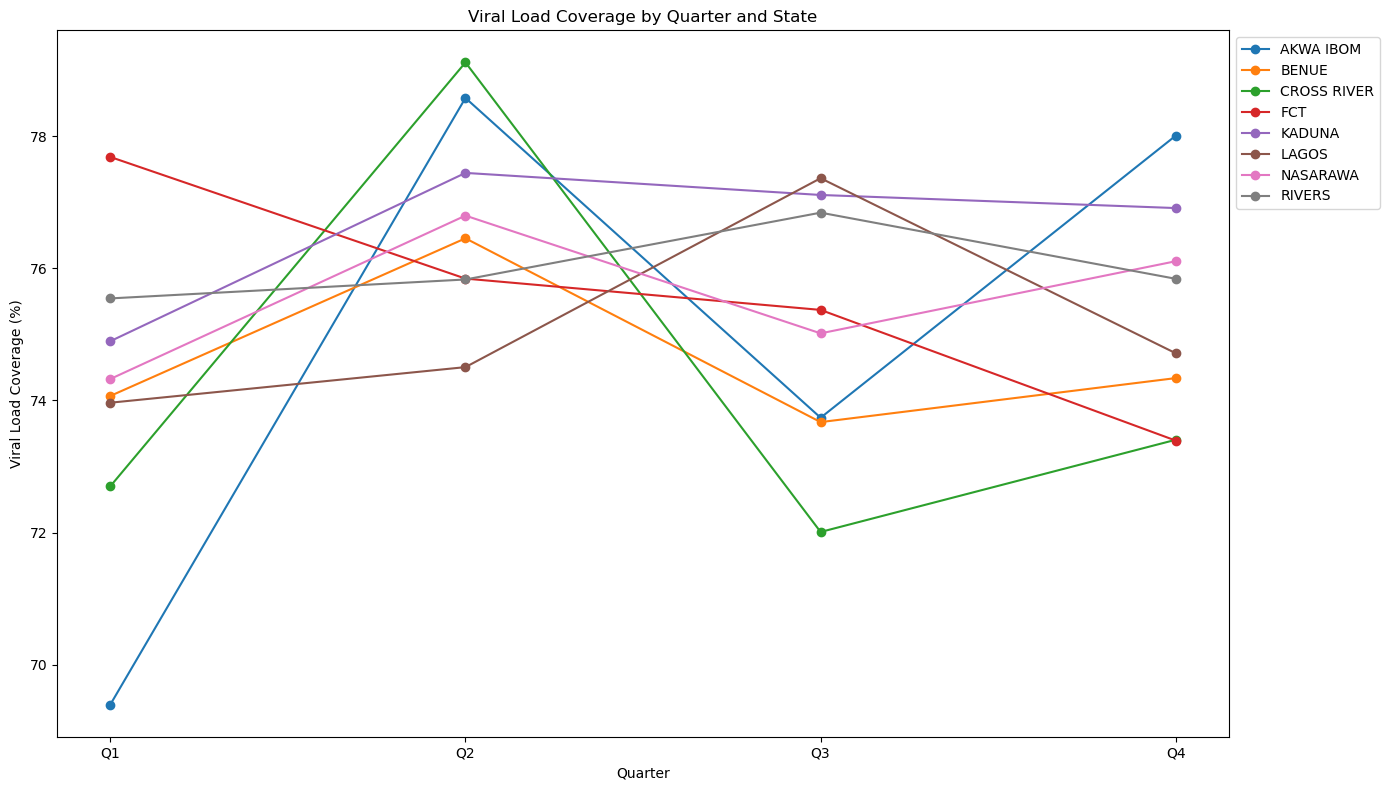

In [230]:
plt.figure(figsize=(14, 8))

for state, data in vl_coverage.groupby("state"):

    data = data.sort_values("quarter")

    plt.plot(
        data["quarter"].astype(str),
        data["vl_coverage"],
        marker="o",
        label=state
    )

plt.title("Viral Load Coverage by Quarter and State")
plt.xlabel("Quarter")
plt.ylabel("Viral Load Coverage (%)")


plt.legend(
    bbox_to_anchor=(1, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "plot_4_viral_load_coverage_by_quarter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [231]:
# Fifth indicator: Viral load suppression by state 
vl_suppression = (
    clean_df .groupby(["state"], as_index=False) .agg(
        vl_result_received=("vl_result_received", "sum"), vl_suppressed=("vl_suppressed", "sum")
    )
)

In [232]:
# Simple vl_suppression calculation
vl_suppression["vl_suppression"] = (
    (vl_suppression["vl_suppressed"] / vl_suppression["vl_result_received"].replace(0, pd.NA)) * 100
)
vl_suppression.head()

,state,vl_result_received,vl_suppressed,vl_suppression
0,AKWA IBOM,345837.00,315006.00,91.09
1,BENUE,479016.00,428914.00,89.54
2,CROSS RIVER,386890.00,342264.00,88.47
3,FCT,650990.00,593052.00,91.10
4,KADUNA,545879.00,486570.00,89.14


In [233]:
# Sixth indicator: PMTCT positivity
pmtct_positive = (
    clean_df.groupby(
        ["facility_id","state"], as_index=False
    ).agg(
        pmtct_stat= ("pmtct_stat", "sum"),
        pmtct_stat_pos= ("pmtct_stat_pos", "sum")
    )
)

In [234]:
# Calculation for the pmtct positivity 
pmtct_positive["pmtct_positivity"] =(
    (pmtct_positive["pmtct_stat_pos"]/ pmtct_positive["pmtct_stat"].replace(0, pd.NA)) * 100
)
pmtct_positive.head()

,facility_id,state,pmtct_stat,pmtct_stat_pos,pmtct_positivity
0,AKS001,AKWA IBOM,3628.00,23,0.63
1,AKS002,AKWA IBOM,1793.00,12,0.67
2,AKS003,AKWA IBOM,3715.00,54,1.45
3,AKS004,AKWA IBOM,1425.00,37,2.60
4,AKS005,AKWA IBOM,821.00,6,0.73


In [235]:
# Sixth indicator: Pmtct art 
pmtct_art = (
    clean_df.groupby(
        ["facility_id", "state"], as_index=False
    ).agg(
        pmtct_art= ("pmtct_art", "sum"),
        pmtct_stat_pos= ("pmtct_stat_pos", "sum")
    )
)


In [236]:
# calculation for the pmtct art
pmtct_art["pmtct_art_coverage"] =(
    (pmtct_art["pmtct_art"]/ pmtct_art["pmtct_stat_pos"].replace(0, pd.NA)) * 100
)
pmtct_art.head()

,facility_id,state,pmtct_art,pmtct_stat_pos,pmtct_art_coverage
0,AKS001,AKWA IBOM,7,23,30.43
1,AKS002,AKWA IBOM,1,12,8.33
2,AKS003,AKWA IBOM,26,54,48.15
3,AKS004,AKWA IBOM,15,37,40.54
4,AKS005,AKWA IBOM,0,6,0.00


In [237]:
# Seventh indicator: reporting completeness
clean_df = clean_df.merge(
    fm[["facility_id", "art_start_date"]],
    on="facility_id",
    how="left"
)

In [238]:
# I converted the art_start_date to pandas date and time format
clean_df["art_start_date"] = pd.to_datetime(
    clean_df["art_start_date"]
)

In [239]:
# Created an expected report column and then checked if the report month is greater than or equal to the art_start_date, and then converted them to month format
clean_df["expected_report"] = (
    clean_df["report_month"].dt.to_period("M")
    >= clean_df["art_start_date"].dt.to_period("M")
)


In [240]:
# Grouped each facility by year, state and month. Summed the total of facility_id reports and the expected report 
completeness = (
    clean_df .groupby(["facility_id", "state", "month"], as_index=False)
    .agg( reports_received=("facility_id", "nunique"),  
         reports_expected=("expected_report", "sum")
    )
)


In [241]:
# calculation on the reporting completeness
completeness["reporting_completeness"] = ((
    completeness["reports_received"] .div( completeness["reports_expected"].replace(0, pd.NA))
    .mul(100)
))
completeness.head()

,facility_id,state,month,reports_received,reports_expected,reporting_completeness
0,AKS001,AKWA IBOM,1,1,3,33.33
1,AKS001,AKWA IBOM,2,1,3,33.33
2,AKS001,AKWA IBOM,3,1,3,33.33
3,AKS001,AKWA IBOM,4,1,3,33.33
4,AKS001,AKWA IBOM,5,1,2,50.00


In [242]:
heatmap_data = completeness.pivot_table(
    index="facility_id",
    columns="month",
    values="reporting_completeness"
)
pd.set_option("display.float_format", "{:.2f}".format)

heatmap_data

month,1,2,3,4,5,6,7,8,9,10,11,12
facility_id,,,,,,,,,,,,
AKS001,33.33,33.33,33.33,33.33,50.00,33.33,33.33,33.33,50.00,50.00,33.33,50.00
AKS002,33.33,33.33,100.00,33.33,33.33,50.00,33.33,25.00,33.33,33.33,33.33,50.00
AKS003,50.00,33.33,50.00,33.33,50.00,33.33,33.33,100.00,33.33,33.33,33.33,33.33
AKS004,33.33,50.00,33.33,33.33,33.33,33.33,50.00,33.33,33.33,33.33,50.00,33.33
AKS005,33.33,33.33,33.33,33.33,50.00,50.00,33.33,33.33,50.00,33.33,33.33,50.00
...,...,...,...,...,...,...,...,...,...,...,...,...
RIV011,33.33,33.33,33.33,33.33,50.00,33.33,50.00,33.33,33.33,25.00,100.00,50.00
RIV012,33.33,33.33,33.33,50.00,33.33,33.33,33.33,33.33,25.00,50.00,33.33,33.33
RIV013,33.33,50.00,33.33,33.33,33.33,33.33,33.33,33.33,33.33,33.33,33.33,50.00


In [243]:
plot_values = heatmap_data.apply(pd.to_numeric)

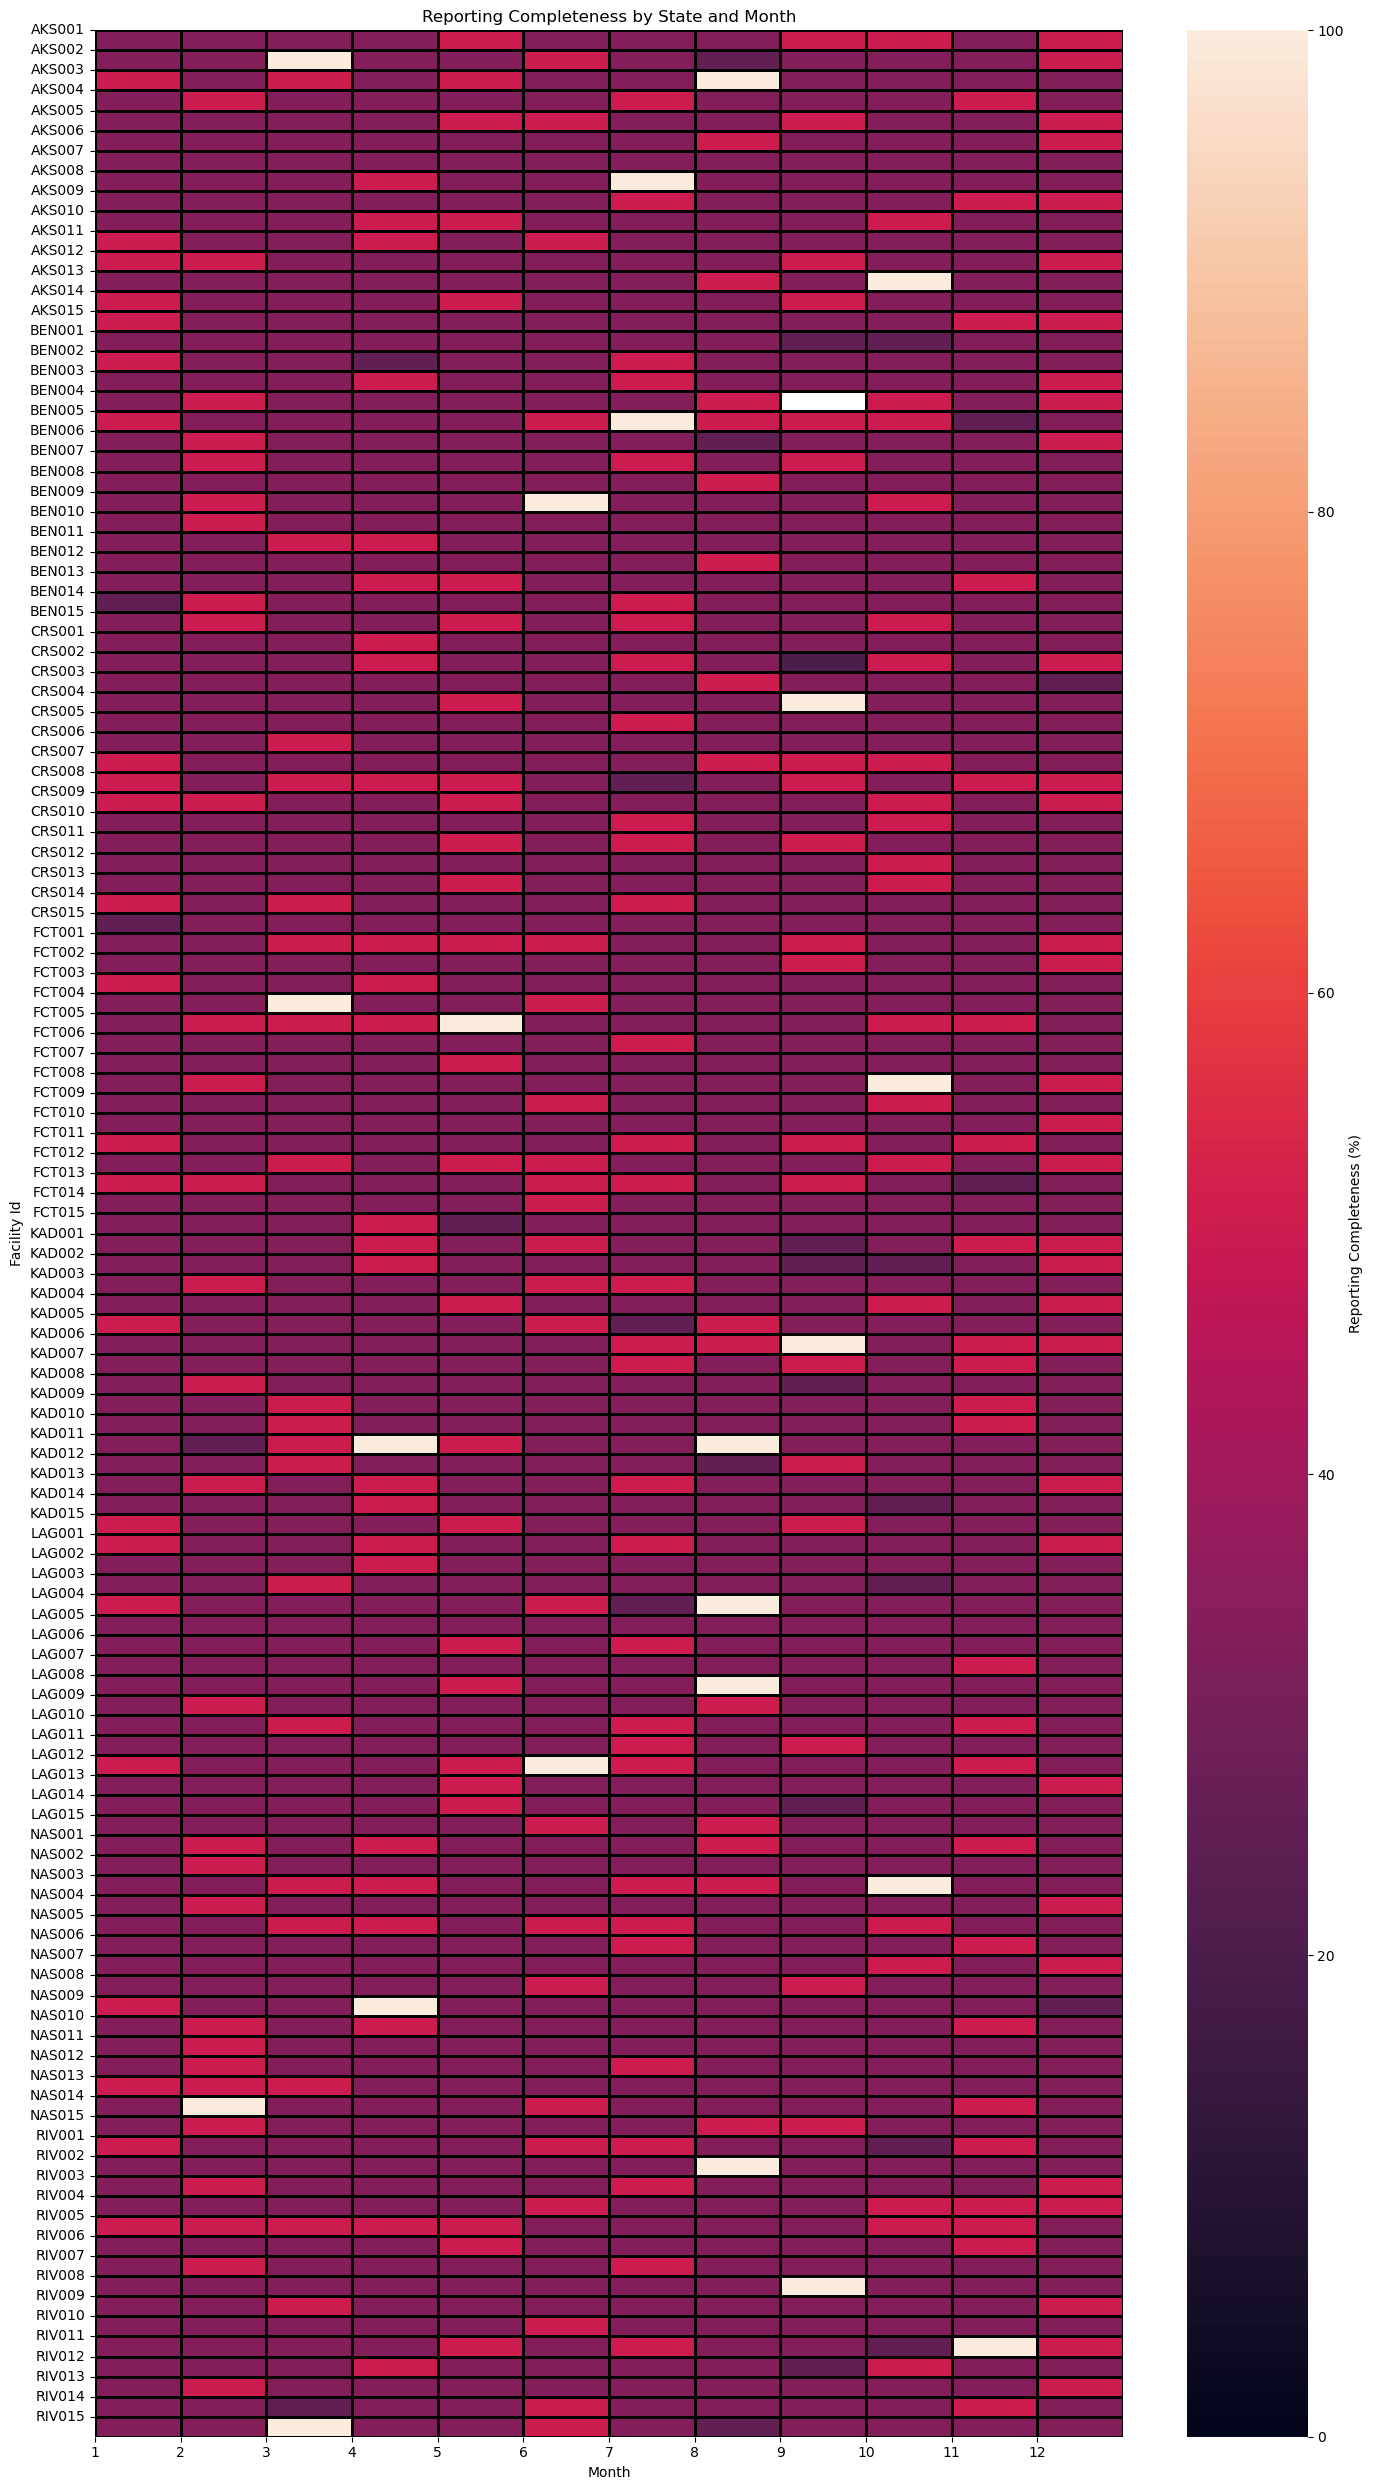

In [244]:
plt.figure(figsize=(14,25))

ax = sns.heatmap(
    plot_values,
    vmin=0,
    vmax=100,
    linewidths=1,
    linecolor= "black",
    cbar_kws={
        "label": "Reporting Completeness (%)"
    }
)


plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Month")
plt.ylabel("Facility Id")
plt.title("Reporting Completeness by State and Month")

plt.tight_layout()
plt.savefig("plot_6_reporting_completeness_heatmap")
plt.show()


In [245]:
completeness["reports_received"]= pd.to_datetime(completeness["reports_received"], errors= "coerce")

In [246]:
# checking if the day in date submitted it less than or equal to 15
clean_df["submitted_by_15"] = (
    completeness["reports_received"].dt.day <= 15
).astype(int)

In [247]:
# Grouping the facility_id and submitted dates by state, months and year
timeliness = (
    clean_df .groupby(["state", "month"], as_index=False)
    .agg(
        reports_received=("facility_id", "nunique"),
        reports_on_time=("submitted_by_15", "sum")
    )
) 


In [248]:
timeliness = (
    clean_df .groupby(["state", "month"], as_index=False)
    .agg(
        reports_received=("facility_id", "nunique"),
        reports_on_time=("submitted_by_15", "sum")
    )
) 


In [249]:
# I got the percentage of the of reprots on time
timeliness["reporting_timeliness"] = (
    timeliness["reports_on_time"] / timeliness["reports_received"].replace(0, pd.NA)
    * 100
).round(2)
timeliness.head()

,state,month,reports_received,reports_on_time,reporting_timeliness
0,AKWA IBOM,1,17,21.00,123.53
1,AKWA IBOM,2,15,15.00,100.00
2,AKWA IBOM,3,18,19.00,105.56
3,AKWA IBOM,4,17,16.00,94.12
4,AKWA IBOM,5,17,12.00,70.59


In [250]:
indicator_1 = hts_tst_state.copy()

indicator_1["indicator"] = "HIV Positivity Yield"

indicator_1 = indicator_1.rename(
    columns={
        "hiv_positivity_yield": "value"
    }
)

indicator_1["unit"] = "Percent"

indicator_1 = indicator_1[
    ["indicator", "state", "year", "facility_level", "value", "unit"]
]

In [251]:
indicator_2 = linkage.copy()

indicator_2["indicator"] = "Linkage Proxy"

indicator_2 = indicator_2.rename(
    columns={
        "linkage_proxy": "value"
    }
)

indicator_2["year"] = 2024
indicator_2["unit"] = "Ratio"

indicator_2 = indicator_2[
    ["indicator", "facility_id", "year", "value", "unit"]
]

In [252]:
indicator_3 = treatment_continuity.copy()

indicator_3["indicator"] = "Treatment Continuity"

indicator_3 = indicator_3.rename(
    columns={
        "net_change": "value"
    }
)

indicator_3["unit"] = "Number of clients"

indicator_3 = indicator_3[
    [
        "indicator",
        "facility_id",
        "year",
        "value",
        "unit",
        "cohort_direction"
    ]
]

In [253]:
indicator_4 = vl_coverage.copy()

indicator_4["indicator"] = "Viral Load Coverage"

indicator_4 = indicator_4.rename(
    columns={
        "vl_coverage": "value"
    }
)

indicator_4["year"] = 2024
indicator_4["unit"] = "Percent"

indicator_4 = indicator_4[
    ["indicator", "state", "year", "quarter", "value", "unit"]
]

In [254]:
indicator_5 = vl_suppression.copy()

indicator_5["indicator"] = "Viral Load Suppression"

indicator_5 = indicator_5.rename(
    columns={
        "vl_suppression": "value"
    }
)

indicator_5["unit"] = "Percent"

indicator_5 = indicator_5[
    ["indicator", "state", "value", "unit"]
]

In [255]:
indicator_6a = pmtct_positive.copy()

indicator_6a["indicator"] = "PMTCT Positivity"

indicator_6a = indicator_6a.rename(
    columns={
        "pmtct_positivity": "value"
    }
)

indicator_6a["unit"] = "Percent"

indicator_6a = indicator_6a[
    ["indicator", "facility_id", "state", "value", "unit"]
]

In [256]:
indicator_6b = pmtct_art.copy()

indicator_6b["indicator"] = "PMTCT ART Coverage"

indicator_6b = indicator_6b.rename(
    columns={
        "pmtct_art_coverage": "value"
    }
)

indicator_6b["unit"] = "Percent"

indicator_6b = indicator_6b[
    ["indicator", "facility_id", "state", "value", "unit"]
]

In [257]:
indicator_7 = completeness.copy()

indicator_7["indicator"] = "Reporting Completeness"

indicator_7 = indicator_7.rename(
    columns={
        "reporting_completeness": "value"
    }
)

indicator_7["unit"] = "Percent"

indicator_7 = indicator_7[
    [
        "indicator",
        "facility_id",
        "state",
        "month",
        "value",
        "unit"
    ]
]

In [258]:
indicator_8 = timeliness.copy()

indicator_8["indicator"] = "Reporting Timeliness"

indicator_8 = indicator_8.rename(
    columns={
        "reporting_timeliness": "value"
    }
)

indicator_8["unit"] = "Percent"

indicator_8 = indicator_8[
    [
        "indicator",
        "state",
        "month",
        "value",
        "unit"
    ]
]

In [327]:
columns = [
    "indicator",
    "facility_id",
    "state",
    "year",
    "quarter",
    "month",
    "facility_level",
    "value",
    "unit",
    "cohort_direction"
]

In [328]:
indicator_tables = [
    indicator_1,
    indicator_2,
    indicator_3,
    indicator_4,
    indicator_5,
    indicator_6a,
    indicator_6b,
    indicator_7,
    indicator_8
]

for table in indicator_tables:
    for column in columns:
        if column not in table.columns:
            table[column] = pd.NA

In [329]:
stage_6_summary = pd.concat(
    indicator_tables,
    ignore_index=True
)

In [330]:
stage_6_summary = stage_6_summary[columns]

In [331]:
stage_6_summary = stage_6_summary.sort_values(
    ["indicator", "state", "year", "facility_id"]
)

In [ ]:
stage_6_summary.head(20)
pd.to_csv(stage_6_summary, "stage_6_summary.csv", index=False)

,indicator,facility_id,state,year,quarter,month,facility_level,value,unit,cohort_direction
0,HIV Positivity Yield,NaN,AKWA IBOM,2022,NaN,<NA>,Primary,2.71,Percent,NaN
1,HIV Positivity Yield,NaN,AKWA IBOM,2022,NaN,<NA>,Secondary,3.88,Percent,NaN
2,HIV Positivity Yield,NaN,AKWA IBOM,2022,NaN,<NA>,Tertiary,1.22,Percent,NaN
3,HIV Positivity Yield,NaN,AKWA IBOM,2023,NaN,<NA>,Primary,2.74,Percent,NaN
4,HIV Positivity Yield,NaN,AKWA IBOM,2023,NaN,<NA>,Secondary,3.68,Percent,NaN
5,HIV Positivity Yield,NaN,AKWA IBOM,2023,NaN,<NA>,Tertiary,1.14,Percent,NaN
6,HIV Positivity Yield,NaN,AKWA IBOM,2024,NaN,<NA>,Primary,2.67,Percent,NaN
7,HIV Positivity Yield,NaN,AKWA IBOM,2024,NaN,<NA>,Secondary,3.20,Percent,NaN
8,HIV Positivity Yield,NaN,AKWA IBOM,2024,NaN,<NA>,Tertiary,1.56,Percent,NaN
9,HIV Positivity Yield,NaN,BENUE,2022,NaN,<NA>,Primary,2.50,Percent,NaN


In [265]:
# Converting the report month to only mnth and year
df["month"] = df["report_month"].dt.to_period("M")
df["month"].head()

0    2022-11
1    2023-04
2    2024-01
3    2022-03
4    2022-01
Name: month, dtype: period[M]

In [266]:
# Calculating the total hts_tst and pos for each month 
monthly_national = (
    df.groupby("month")[["hts_tst", "hts_tst_pos"]]
    .sum()
    .reset_index()
)

In [267]:
# Calculated a 3 month rolling average 
monthly_national["hts_tst_rolling_3"] = (
    monthly_national["hts_tst"].rolling(3).mean()
)


In [268]:
# Same for the pos
monthly_national["hts_tst_pos_rolling_3"] = (
    monthly_national["hts_tst_pos"].rolling(3).mean()
)
monthly_national.head()

,month,hts_tst,hts_tst_pos,hts_tst_rolling_3,hts_tst_pos_rolling_3
0,2022-01,73286.00,1865.00,NaN,NaN
1,2022-02,80954.00,1836.00,NaN,NaN
2,2022-03,71278.00,2060.00,75172.67,1920.33
3,2022-04,76005.00,4675.00,76079.00,2857.00
4,2022-05,85401.00,6960.00,77561.33,4565.00


In [269]:
# Covert period data to datetime index
monthly_national["month"] = monthly_national["month"].dt.to_timestamp()

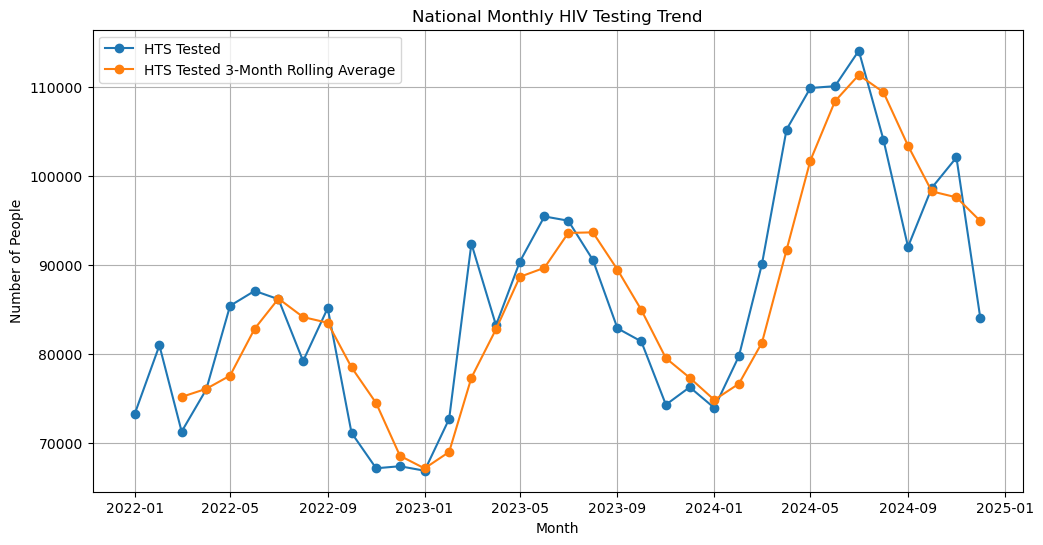

In [270]:
# Plot month against hts_tst
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_national["month"],
    monthly_national["hts_tst"],
    label="HTS Tested",
    marker= "o"
)

plt.plot(
    monthly_national["month"],
    monthly_national["hts_tst_rolling_3"],
    label="HTS Tested 3-Month Rolling Average",
    marker= "o"
)

plt.xlabel("Month")
plt.ylabel("Number of People")
plt.title("National Monthly HIV Testing Trend")
plt.legend()

plt.grid()

plt.savefig(
    "plot_1_HIV_ 3_month_rolling_average.png"
)
plt.show()

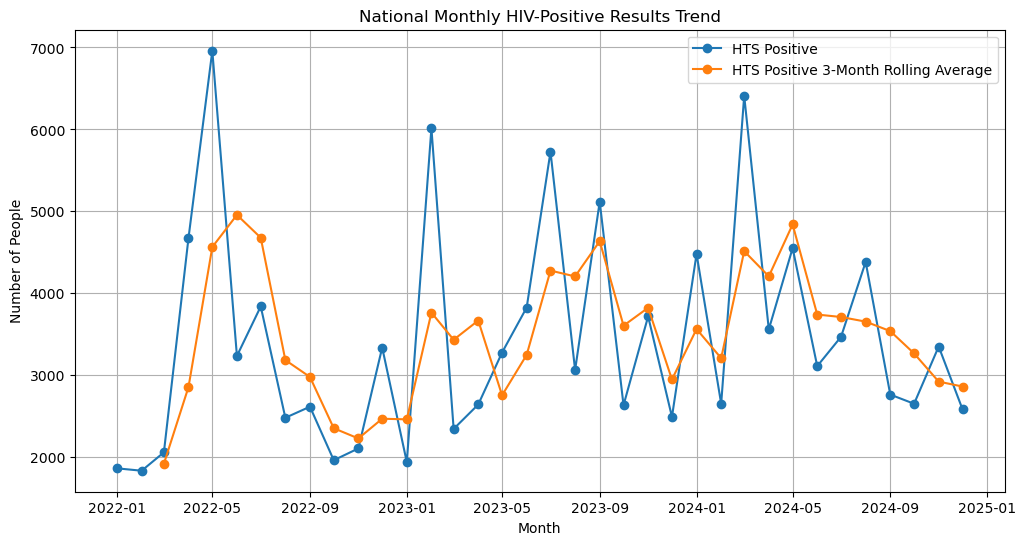

In [271]:
# Plot month againt hts_tst_pos 
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_national["month"],
    monthly_national["hts_tst_pos"],
    label="HTS Positive",
    marker= "o"
)

plt.plot(
    monthly_national["month"],
    monthly_national["hts_tst_pos_rolling_3"],
    label="HTS Positive 3-Month Rolling Average",
    marker = "o"
)

plt.xlabel("Month")
plt.ylabel("Number of People")
plt.title("National Monthly HIV-Positive Results Trend")
plt.legend()

plt.grid()

plt.savefig(
    "plot_1_HIV_positive_ 3_month_rolling_average.png"
)
plt.show()

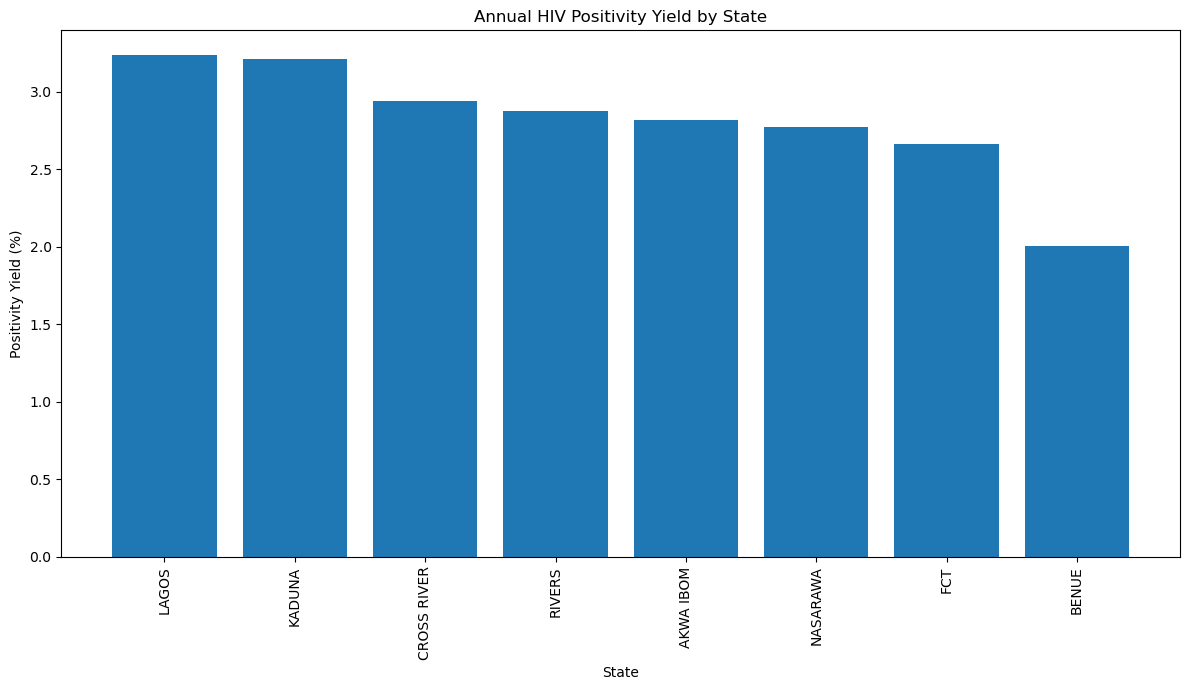

In [272]:
# Calculate annual positivity yield by state
positivity_state = (
    clean_df.groupby("state")
    [["hts_tst", "hts_tst_pos"]].sum()
    .reset_index()
)

positivity_state["positivity_yield"] = (
    positivity_state["hts_tst_pos"] /
    positivity_state["hts_tst"] * 100
)

# Sort highest to lowest
positivity_state = positivity_state.sort_values(
    "positivity_yield",
    ascending=False
)

plt.figure(figsize=(12, 7))

plt.bar(
    positivity_state["state"],
    positivity_state["positivity_yield"]
)

plt.title("Annual HIV Positivity Yield by State")
plt.xlabel("State")
plt.ylabel("Positivity Yield (%)")
plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "plot_2_annual_positivity_yield_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [273]:
# Create a year column from the report months 
df["year"] = df["report_month"].dt.year

In [274]:
# Checking
df[["report_month", "year"]].head()

,report_month,year
0,2022-11-30,2022
1,2023-04-30,2023
2,2024-01-31,2024
3,2022-03-31,2022
4,2022-01-31,2022


In [275]:
# Getting the report months that are in december to calculate the year on year grouth in tx_curr by state
december = df[df["report_month"].dt.month == 12]

In [276]:
# Calculating the sum of december tx_curr by state and year
tx_curr_yearly= (
    december.groupby(["state", "year"])
    ["tx_curr"].sum().reset_index()
    )
tx_curr_yearly

,state,year,tx_curr
0,AKWA IBOM,2022,19401
1,AKWA IBOM,2023,16246
2,AKWA IBOM,2024,16108
3,BENUE,2022,22853
4,BENUE,2023,22393
5,BENUE,2024,20319
6,CROSS RIVER,2022,18945
7,CROSS RIVER,2023,23841
8,CROSS RIVER,2024,18356
9,FCT,2022,31991


In [277]:

tx_curr_yearly["previous_year"] = (
    tx_curr_yearly.groupby("state")["tx_curr"].shift(1)
)

In [278]:
# Calculating the difference between the tx_curr by year 
tx_curr_yearly["yoy_growth"] = (
    (tx_curr_yearly["tx_curr"] - tx_curr_yearly["previous_year"])
    / tx_curr_yearly["previous_year"]
) * 100
tx_curr_yearly

,state,year,tx_curr,previous_year,yoy_growth
0,AKWA IBOM,2022,19401,<NA>,<NA>
1,AKWA IBOM,2023,16246,19401,-16.26
2,AKWA IBOM,2024,16108,16246,-0.85
3,BENUE,2022,22853,<NA>,<NA>
4,BENUE,2023,22393,22853,-2.01
5,BENUE,2024,20319,22393,-9.26
6,CROSS RIVER,2022,18945,<NA>,<NA>
7,CROSS RIVER,2023,23841,18945,25.84
8,CROSS RIVER,2024,18356,23841,-23.01
9,FCT,2022,31991,<NA>,<NA>


In [279]:
# Getting the year and month from the month column we cretaed earlier  
monthly_national["year"] = monthly_national["month"].dt.year
monthly_national["calendar_month"] = monthly_national["month"].dt.month

In [280]:
# Calculating the avaerage hts_tst by each month 
seasonality = (
    monthly_national.groupby("calendar_month")
    ["hts_tst"].mean().round(2)
    .reset_index()
)

In [281]:
# Giving each month a month name 
import calendar

seasonality["month_name"] = seasonality["calendar_month"].apply(
    lambda x: calendar.month_name[x]
)
seasonality

,calendar_month,hts_tst,month_name
0,1,71369.67,January
1,2,77804.33,February
2,3,84581.67,March
3,4,88135.33,April
4,5,95201.67,May
5,6,97522.00,June
6,7,98376.33,July
7,8,91270.33,August
8,9,86680.00,September
9,10,83730.00,October


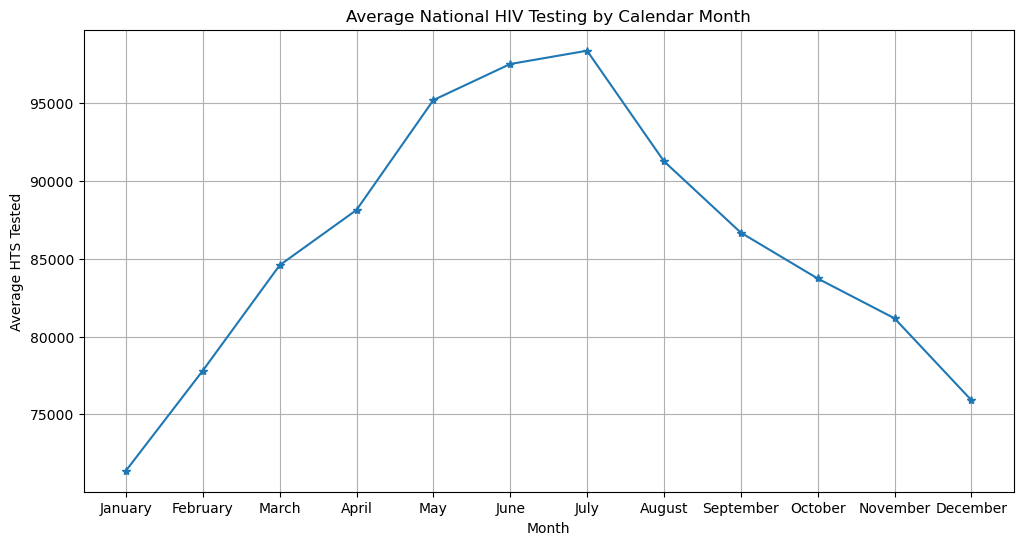

In [282]:
# plotting the graph for seasonality to see if there is a month or quarter that consistenly dips of peaks 
plt.figure(figsize=(12, 6))

plt.plot(
    seasonality["month_name"],
    seasonality["hts_tst"],
    marker="*"
)

plt.xlabel("Month")
plt.ylabel("Average HTS Tested")
plt.title("Average National HIV Testing by Calendar Month")

plt.grid()
plt.show()

In [283]:
# Getting the month and state with the highest hts_tst 
seasonality.loc[seasonality["hts_tst"].idxmax()]

calendar_month          7
hts_tst          98376.33
month_name           July
Name: 6, dtype: object

In [284]:
# Vice versa
seasonality.loc[seasonality["hts_tst"].idxmin()]

calendar_month          1
hts_tst          71369.67
month_name        January
Name: 0, dtype: object

In [285]:
#Pivot table showing the sum of the hts_tst by year and calendar month 
seasonality_years = monthly_national.pivot_table(
    index="calendar_month",
    columns="year",
    values="hts_tst",
    aggfunc= "sum"
).reset_index()
seasonality_years

year,calendar_month,2022,2023,2024
0,1,73286.00,66885.00,73938.00
1,2,80954.00,72708.00,79751.00
2,3,71278.00,92386.00,90081.00
3,4,76005.00,83211.00,105190.00
4,5,85401.00,90352.00,109852.00
5,6,87076.00,95433.00,110057.00
6,7,86138.00,94954.00,114037.00
7,8,79197.00,90554.00,104060.00
8,9,85142.00,82872.00,92026.00
9,10,71139.00,81403.00,98648.00


In [286]:
# gets the min and max reprot month by month start 
all_months = pd.date_range(
    start=df["report_month"].min(),
    end=df["report_month"].max(),
    freq="MS" 
)


In [287]:
 # Gets every unique faciltiy_id and reprot month that where reproted 
facility_months = (
    df[["facility_id", "report_month"]].drop_duplicates()
)

In [288]:
# Gets every unique faciltiy id and creates a report month combination for all months.
facilities = df["facility_id"].drop_duplicates()

expected = pd.MultiIndex.from_product(
    [facilities, all_months],
    names=["facility_id", "report_month"]
).to_frame(index=False)


In [289]:
# Merging the expected reports with the actual reprots to see which facility didn't have a reprot month
reporting_check = expected.merge(
    facility_months,
    on=["facility_id", "report_month"],
    how="left",
    indicator=True
)
reporting_check["_merge"].value_counts()

_merge
left_only     4033
both           431
right_only       0
Name: count, dtype: int64

In [290]:
# Fcailties that didnt have a report month
gaps = reporting_check[
    reporting_check["_merge"] == "left_only"
].copy()
gaps

,facility_id,report_month,_merge
0,FCT012,2022-01-01,left_only
1,FCT012,2022-02-01,left_only
2,FCT012,2022-03-01,left_only
5,FCT012,2022-06-01,left_only
6,FCT012,2022-07-01,left_only
...,...,...,...
4458,AKS010,2024-07-01,left_only
4459,AKS010,2024-08-01,left_only
4460,AKS010,2024-09-01,left_only
4461,AKS010,2024-10-01,left_only


In [291]:
# For every facilty with a missing reprot the i got when the reprot stared missing till when it stopped and the counts of the missing months.
gap_summary = (
    gaps.groupby("facility_id")
    .agg(
        gap_start=("report_month", "min"),
        gap_end=("report_month", "max"),
        missing_months=("report_month", "count")
    )
    .reset_index()
)

In [292]:
# Missing months that are more that 2
multi_month_gaps = gap_summary[
    gap_summary["missing_months"] >= 4
].copy()

In [293]:
# The top 3 facilites with missing records
top_3_gaps = (
    multi_month_gaps
    .sort_values("missing_months", ascending=False) 
)
top_3_gaps.head(3)

,facility_id,gap_start,gap_end,missing_months
71,KAD012,2022-01-01,2024-12-01,36
0,AKS001,2022-01-01,2024-12-01,35
26,BEN012,2022-01-01,2024-12-01,35


In [294]:
# Importing the viral load csv 
vl = pd.read_csv("viral_load_samples_2024.csv")

In [295]:
vl.shape

(11157, 12)

In [296]:
# Checking the data set 
vl.head()

,sample_id,facility_id,state,sex,age_years,regimen_line,date_collected,date_received_lab,date_result_dispatched,result_copies_per_ml,result_flag,rejection_reason
0,VL108797,CRS004,Cross River,Male,31,1st line,2024-08-18,2024-08-21,2024-09-03,669,Valid,NaN
1,VL105525,LAG011,Lagos,Male,2,1st line,2024-09-21,2024-09-25,2024-10-07,81,Valid,NaN
2,VL105269,LAG009,Lagos,Male,2,1st line,2024-04-12,2024-04-17,2024-04-22,628,Valid,NaN
3,VL101254,AKS014,Akwa Ibom,Male,58,1st line,2024-07-29,2024-08-02,2024-08-14,24,Valid,NaN
4,VL100676,AKS006,Akwa Ibom,Female,47,1st line,2024-04-24,2024-05-04,2024-05-26,939,Valid,NaN


In [297]:
# Converting all date columsn to date and time format in pandas 
date_cols = [
    "date_collected",
    "date_received_lab",
    "date_result_dispatched"
]

for col in date_cols:
    vl[col] = pd.to_datetime(vl[col], errors= "coerce")


In [298]:
# when the facility recieved the sample after collection
vl["facility_to_lab_days"] = (
    vl["date_received_lab"] - vl["date_collected"]
).dt.days

In [299]:
# Hwo long it took the facility for finish processing the results 
vl["lab_processing_days"] = (
    vl["date_result_dispatched"] - vl["date_received_lab"]
).dt.days

In [300]:
# total turn around time 
vl["total_tat_days"] = (
    vl["facility_to_lab_days"] + vl["lab_processing_days"]
)
vl["total_tat_days"].head()

0   16.00
1   16.00
2   10.00
3   16.00
4   32.00
Name: total_tat_days, dtype: float64

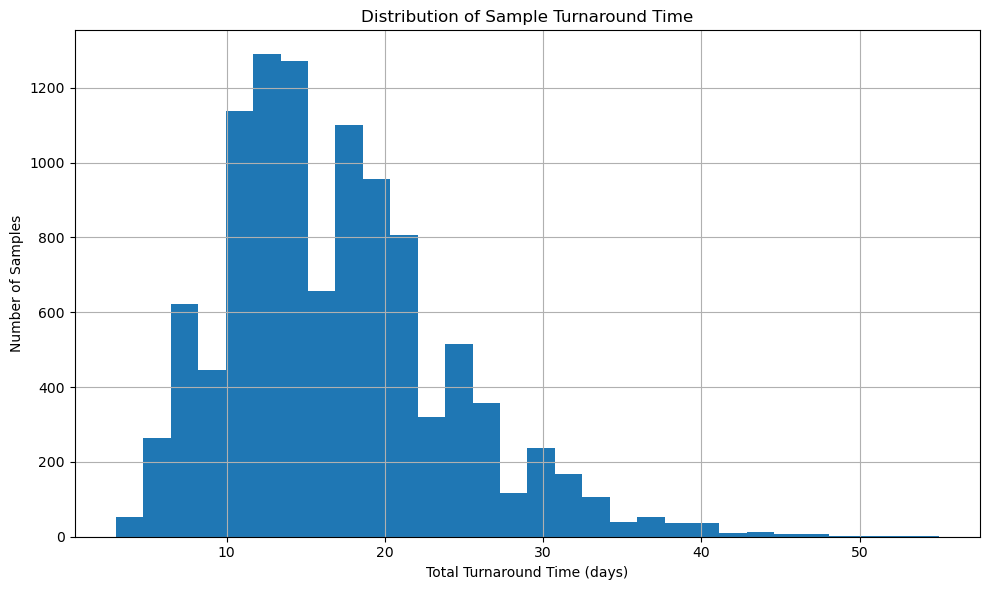

In [301]:
plt.figure(figsize=(10, 6))

plt.hist(
    vl["total_tat_days"].dropna(),
    bins=30
)

plt.title("Distribution of Sample Turnaround Time")
plt.xlabel("Total Turnaround Time (days)")
plt.ylabel("Number of Samples")
plt.grid()

plt.tight_layout()

plt.savefig(
    "plot_5_turnaround_time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [302]:
vl[date_cols].isna().sum()

date_collected              0
date_received_lab           0
date_result_dispatched    526
dtype: int64

In [303]:
# Invalid dates includes, the dates lab recieved exceed the date samples where collected, or the dates lab recieved exceeds the date result dispached and any of the date_cols that is NA
vl["invalid_dates"] = (
    (vl["date_received_lab"] < vl["date_collected"]) |
    (vl["date_result_dispatched"] < vl["date_received_lab"]) |
    vl[date_cols].isna().any(axis=1)
)


In [304]:
# Converted all invalid dates and their total turn aorund time to pd.NA
vl.loc[vl["invalid_dates"], "total_tat_days"] = pd.NA

In [305]:
# Converted the result copies to numeric
vl["result_clean"] = pd.to_numeric(vl["result_copies_per_ml"], errors= "coerce")

In [306]:
# Checking how many values where lab conventions 
vl[vl["result_copies_per_ml"].astype(str).str.strip().str.lower()
   .isin(["tnd", "not detected", "<50", "ldl"])
]["result_copies_per_ml"].value_counts()

result_copies_per_ml
LDL             10
TND              9
Not detected     8
<50              5
Name: count, dtype: int64

In [307]:
text_suppressed = (
    vl["result_copies_per_ml"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["tnd", "not detected", "<50", "ldl"])
)

vl["suppressed"] = (
    (vl["result_clean"] < 1000) |
    text_suppressed
)

In [308]:
# Checks how many rejected result that carry a nuerical values 
rejected_with_result = vl[
    vl["result_flag"].str.strip().str.lower().eq("rejected") &
    vl["result_copies_per_ml"].notna()
]

len(rejected_with_result)

30

In [309]:
# Checks how many valid result that dont carry a numerical value
valid_no_numeric_result = vl[
    vl["result_flag"].str.strip().str.lower().eq("valid") &
    vl["result_clean"].isna()
]

len(valid_no_numeric_result)

40

In [310]:
# Checking sample id duplicates
duplicates = vl[
    vl["sample_id"].duplicated(keep= False)
].sort_values("sample_id")

duplicates


,sample_id,facility_id,state,sex,age_years,regimen_line,date_collected,date_received_lab,date_result_dispatched,result_copies_per_ml,result_flag,rejection_reason,facility_to_lab_days,lab_processing_days,total_tat_days,invalid_dates,result_clean,suppressed
4602,VL100243,AKS002,Akwa Ibom,Female,69,1st line,2024-09-06,2024-09-15,2024-10-03,893,Valid,NaN,9,18.00,27.00,False,893.00,True
1945,VL100243,AKS002,Akwa Ibom,Female,69,1st line,2024-09-06,2024-09-15,2024-10-03,893,Valid,NaN,9,18.00,27.00,False,893.00,True
8177,VL100531,AKS004,Akwa Ibom,Female,14,1st line,2024-05-02,2024-05-07,2024-05-24,218,Valid,NaN,5,17.00,22.00,False,218.00,True
6445,VL100531,AKS004,Akwa Ibom,Female,14,1st line,2024-05-02,2024-05-07,2024-05-24,218,Valid,NaN,5,17.00,22.00,False,218.00,True
297,VL100556,AKS005,Akwa Ibom,Female,47,1st line,2024-02-22,2024-02-25,2024-03-02,90800,Valid,NaN,3,6.00,9.00,False,90800.00,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7567,VL110068,NAS004,Nasarawa,Male,46,2nd line,2024-11-15,2024-11-25,2024-12-02,658,Valid,NaN,10,7.00,17.00,False,658.00,True
8125,VL110615,NAS009,Nasarawa,Female,66,1st line,2024-05-09,2024-05-12,2024-05-30,736,Valid,NaN,3,18.00,21.00,False,736.00,True
6258,VL110615,NAS009,Nasarawa,Female,66,1st line,2024-05-09,2024-05-12,2024-05-30,736,Valid,NaN,3,18.00,21.00,False,736.00,True
6144,VL111008,NAS014,Nasarawa,Female,7,1st line,2024-03-21,2024-03-25,NaT,NaN,Rejected,Expired collection tube,4,NaN,NaN,True,NaN,False


In [311]:
duplicates["sample_id"].nunique()

35

In [312]:
# age years less then 0
vl[vl["age_years"]< 0]

,sample_id,facility_id,state,sex,age_years,regimen_line,date_collected,date_received_lab,date_result_dispatched,result_copies_per_ml,result_flag,rejection_reason,facility_to_lab_days,lab_processing_days,total_tat_days,invalid_dates,result_clean,suppressed
886,VL101900,RIV007,Rivers,Female,-3,1st line,2024-12-16,2024-12-18,2025-01-07,425,Valid,NaN,2,20.00,22.00,False,425.00,True
3133,VL105959,LAG015,Lagos,Male,-3,1st line,2024-06-30,2024-07-01,NaT,NaN,Rejected,Insufficient volume,1,NaN,NaN,True,NaN,False
7996,VL108052,KAD012,Kaduna,Female,-3,1st line,2024-09-20,2024-09-25,2024-10-06,835,Valid,NaN,5,11.00,16.00,False,835.00,True
9198,VL101038,AKS011,Akwa Ibom,Female,-3,1st line,2024-04-04,2024-04-10,2024-04-25,946,Valid,NaN,6,15.00,21.00,False,946.00,True
9537,VL100328,AKS003,Akwa Ibom,Female,-3,1st line,2024-01-02,2024-01-06,2024-01-24,468,Valid,NaN,4,18.00,22.00,False,468.00,True


In [313]:
# age years less then 120
vl[vl["age_years"]> 120]

,sample_id,facility_id,state,sex,age_years,regimen_line,date_collected,date_received_lab,date_result_dispatched,result_copies_per_ml,result_flag,rejection_reason,facility_to_lab_days,lab_processing_days,total_tat_days,invalid_dates,result_clean,suppressed
242,VL102900,BEN002,Benue,Male,132,1st line,2024-12-26,2024-12-29,2025-01-08,94,Valid,NaN,3,10.00,13.00,False,94.00,True
2524,VL101989,RIV008,Rivers,Female,132,1st line,2024-10-02,2024-10-08,2024-10-27,935,Valid,NaN,6,19.00,25.00,False,935.00,True
2720,VL110390,NAS007,Nasarawa,Male,250,1st line,2024-02-05,2024-02-13,2024-03-08,502,Valid,NaN,8,24.00,32.00,False,502.00,True
2982,VL104079,BEN013,Benue,Male,199,1st line,2024-04-26,2024-05-01,2024-05-07,609,Valid,NaN,5,6.00,11.00,False,609.00,True
3831,VL102508,RIV014,Rivers,Male,250,1st line,2024-05-24,2024-05-31,2024-06-19,669,Valid,NaN,7,19.00,26.00,False,669.00,True
3991,VL110070,NAS004,Nasarawa,Male,250,1st line,2024-12-02,2024-12-09,2025-01-11,918,Valid,NaN,7,33.00,40.00,False,918.00,True
4993,VL100061,AKS001,Akwa Ibom,Female,132,1st line,2024-01-26,2024-01-28,NaT,NaN,Rejected,Sample leaked in transit,2,NaN,NaN,True,NaN,False
5060,VL103770,BEN010,Benue,Female,199,1st line,2024-06-16,2024-06-22,2024-07-08,84079,Valid,NaN,6,16.00,22.00,False,84079.00,False
5869,VL102926,BEN002,Benue,Female,132,1st line,2024-05-10,2024-05-16,2024-05-22,548,Valid,NaN,6,6.00,12.00,False,548.00,True
6366,VL106936,FCT014,FCT,Female,199,1st line,2024-09-18,2024-09-26,2024-09-30,624,Valid,NaN,8,4.00,12.00,False,624.00,True


In [314]:
# Sum of invalid ages 
(
    (vl["age_years"]< 0) |
    (vl["age_years"]> 120)
).sum()

20

In [315]:
# Median and 90 percentile by state
tat_by_state = (
    vl.dropna(subset=["total_tat_days"])
      .groupby("state")
      ["total_tat_days"].agg(
          median_tat="median",
          p90_tat=lambda x: x.quantile(0.90)
      )
      .reset_index()
)

tat_by_state

,state,median_tat,p90_tat
0,Akwa Ibom,16.00,27.00
1,Benue,16.00,26.00
2,Cross River,16.00,25.00
3,FCT,16.00,27.00
4,Kaduna,16.00,26.00
5,Lagos,16.00,26.00
6,Nasarawa,16.00,27.00
7,Rivers,16.00,26.00


In [316]:
rejection_by_facility = (
    vl.assign(
        rejected=vl["result_flag"].str.strip().str.lower().eq("rejected")
    )
    .groupby("facility_id")
    .agg(
        total_samples=("sample_id", "size"),
        rejected_samples=("rejected", "sum")
    )
    .reset_index()
)
rejection_by_facility

,facility_id,total_samples,rejected_samples
0,AKS001,152,7
1,AKS002,92,4
2,AKS003,155,6
3,AKS004,146,6
4,AKS005,58,3
...,...,...,...
115,RIV011,86,3
116,RIV012,93,5
117,RIV013,46,1
118,RIV014,135,7


In [317]:
rejection_by_facility["rejection_rate"] = (
    rejection_by_facility["rejected_samples"] / rejection_by_facility["total_samples"] * 100
)

In [318]:
rejection_by_facility.sort_values("rejection_rate",ascending=False).head(10)

,facility_id,total_samples,rejected_samples,rejection_rate
50,FCT006,44,5,11.36
114,RIV010,96,9,9.38
91,NAS002,99,9,9.09
72,KAD013,81,7,8.64
100,NAS011,48,4,8.33
71,KAD012,122,10,8.20
112,RIV008,98,8,8.16
26,BEN012,88,7,7.95
19,BEN005,104,8,7.69
54,FCT010,80,6,7.50


In [319]:
vl["rejection_reason"].value_counts(dropna = False)

rejection_reason
NaN                         10631
Improper labelling            117
Insufficient volume           107
Sample leaked in transit      103
Haemolysed sample             103
Expired collection tube        96
Name: count, dtype: int64

In [320]:
has_result = (
    vl["result_clean"].notna() |
    text_suppressed
)

In [321]:
suppression_rate = (
    vl.loc[has_result, "suppressed"].mean()* 100
)

suppression_rate

90.71623016990519

In [322]:
suppression_by_sex = (
    vl[has_result]
    .groupby("sex")
    ["suppressed"].mean().mul(100)
    .reset_index()
)

suppression_by_sex

,sex,suppressed
0,Female,90.87
1,Male,90.47


In [323]:
bins = [0, 14, 24, 34, 44, 54, 64, 120]

labels =[
    "0-14",
    "15-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

vl["age_group"] = pd.cut(
    vl["age_years"],
    bins=bins,
    labels=labels,
    include_lowest= True
)
vl.head()

,sample_id,facility_id,state,sex,age_years,regimen_line,date_collected,date_received_lab,date_result_dispatched,result_copies_per_ml,result_flag,rejection_reason,facility_to_lab_days,lab_processing_days,total_tat_days,invalid_dates,result_clean,suppressed,age_group
0,VL108797,CRS004,Cross River,Male,31,1st line,2024-08-18,2024-08-21,2024-09-03,669,Valid,NaN,3,13.00,16.00,False,669.00,True,25-34
1,VL105525,LAG011,Lagos,Male,2,1st line,2024-09-21,2024-09-25,2024-10-07,81,Valid,NaN,4,12.00,16.00,False,81.00,True,0-14
2,VL105269,LAG009,Lagos,Male,2,1st line,2024-04-12,2024-04-17,2024-04-22,628,Valid,NaN,5,5.00,10.00,False,628.00,True,0-14
3,VL101254,AKS014,Akwa Ibom,Male,58,1st line,2024-07-29,2024-08-02,2024-08-14,24,Valid,NaN,4,12.00,16.00,False,24.00,True,55-64
4,VL100676,AKS006,Akwa Ibom,Female,47,1st line,2024-04-24,2024-05-04,2024-05-26,939,Valid,NaN,10,22.00,32.00,False,939.00,True,45-54


In [324]:
suppression_by_age = (
    vl[has_result]
    .groupby("age_group", observed=True)["suppressed"]
    .mean()
    .mul(100)
    .reset_index(name="suppression_rate")
)

suppression_by_age

,age_group,suppression_rate
0,0-14,91.69
1,15-24,89.90
2,25-34,90.53
3,35-44,91.32
4,45-54,90.62
5,55-64,90.25
6,65+,90.44


In [325]:
vl["regimen_line"].value_counts(dropna=False)

regimen_line
1st line    9667
2nd line    1376
3rd line     114
Name: count, dtype: int64

In [326]:
suppression_by_regimen = (
    vl[has_result]
    .groupby("regimen_line")
    ["suppressed"].mean().mul(100)
    .reset_index(name="suppression")
)

suppression_by_regimen

,regimen_line,suppression
0,1st line,90.57
1,2nd line,91.83
2,3rd line,89.38
